## Loading the data 
Loading datasets and combining them to a whole single dataframe

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:

# 1. Load the core Olist datasets
path = '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/'
orders = pd.read_csv(path + 'olist_orders_dataset.csv')
items = pd.read_csv(path + 'olist_order_items_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
payments = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')

# 2. Merge them together on their keys
# Merge items with orders
df = pd.merge(items, orders, on='order_id', how='left')
# Add customer info
df = pd.merge(df, customers, on='customer_id', how='left')
# Add product info
df = pd.merge(df, products, on='product_id', how='left')
# Add reviews
df = pd.merge(df, reviews, on='order_id', how='left')
# Add payments (taking the first payment method if there are multiple)
payments_agg = payments.groupby('order_id')['payment_type'].first().reset_index()
df = pd.merge(df, payments_agg, on='order_id', how='left')

# 3. Map to the Capstone Schema (Renaming)
df = df.rename(columns={
    'order_id': 'Order_ID',
    'customer_unique_id': 'Customer_ID',
    'customer_state': 'Area',
    'product_category_name': 'Category',
    'product_id': 'Product_ID',
    'price': 'Unit_Price',
    'order_item_id': 'Quantity', # Olist uses multiple rows per item, we can treat item_id as proxy or group
    'payment_type': 'Payment_Method',
    'order_delivered_customer_date': 'Actual_Delivery_Days', # Will need date math later
    'order_estimated_delivery_date': 'Expected_Delivery_Days',
    'order_status': 'Delivery_Status',
    'review_score': 'Rating',
    'order_purchase_timestamp': 'Order_Date'
})

print(f"Merged dataset shape: {df.shape}")
display(df.head())


Merged dataset shape: (113314, 33)


,Order_ID,Quantity,Product_ID,seller_id,shipping_limit_date,Unit_Price,freight_value,customer_id,Delivery_Status,Order_Date,...,product_length_cm,product_height_cm,product_width_cm,review_id,Rating,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,Payment_Method
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,28.0,9.0,14.0,97ca439bc427b48bc1cd7177abe71365,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03,credit_card
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,50.0,30.0,40.0,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13,credit_card
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,33.0,13.0,33.0,0c5b33dea94867d1ac402749e5438e8b,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31,credit_card
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,16.0,10.0,15.0,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,35.0,40.0,30.0,940144190dcba6351888cafa43f3a3a5,5.0,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59,credit_card


## Simulate schema needed in the rubric

In [24]:
# --- SIMULATE MISSING SCHEMA COLUMNS ---
np.random.seed(42) # Keeps the random data the same every time you run it!
n_rows = len(df)

# Customer Group
df['Gender'] = np.random.choice(['M', 'F'], n_rows)
df['Age'] = np.random.randint(18, 75, n_rows)

# Store & Channel
df['Branch'] = np.random.choice(['North', 'South', 'East', 'West'], n_rows)
df['Sales_Channel'] = 'Online'

# Product (Simulating Brand and Domain based on existing category)
df['Brand'] = np.random.choice(['Brand_A', 'Brand_B', 'Brand_C', 'Generic'], n_rows)
df['Product_Domain'] = 'Retail'
df['Name'] = 'Product_' + df['Product_ID'].astype(str).str[:5]

# Sales & Pricing
df['Discount_Percent'] = np.random.choice([0, 5, 10, 15, 20], n_rows, p=[0.5, 0.2, 0.15, 0.1, 0.05])
df['Competitor_Price'] = df['Unit_Price'] * np.random.uniform(0.9, 1.1, n_rows)

# Marketing
df['Marketing_Source'] = np.random.choice(['Google', 'Facebook', 'Direct', 'Email'], n_rows)
df['Campaign_Name'] = np.where(df['Marketing_Source'] == 'Direct', 'No Campaign', 'Promo_2023')

# Delivery
df['Courier'] = np.random.choice(['Courier A', 'Courier B', 'Courier C'], n_rows)

# Returns & Feedback
df['Returned'] = np.random.choice(['Yes', 'No'], n_rows, p=[0.08, 0.92]) # 8% return rate

# Generate the random arrays first
return_reasons = np.random.choice(['Defective', 'Changed Mind', 'Wrong Item'], n_rows)
refund_methods = np.random.choice(['Credit', 'Original Form'], n_rows)

# Apply PDF rule: "Return fields null when Returned=No" (using None fixes the NumPy dtype error)
df['Return_Reason'] = np.where(df['Returned'] == 'Yes', return_reasons, None)
df['Complaint_Text'] = np.where(df['Returned'] == 'Yes', 'User filed complaint', None)
df['Request_Date'] = np.where(df['Returned'] == 'Yes', df['Order_Date'], None) 
df['Refund_Method'] = np.where(df['Returned'] == 'Yes', refund_methods, None)

# Inventory & External
df['Stock_Available_Before_Sale'] = np.random.randint(0, 100, n_rows)
df['Supplier'] = np.random.choice(['Supplier_X', 'Supplier_Y', 'Supplier_Z'], n_rows)
df['Lead_Time_Days'] = np.random.randint(1, 14, n_rows)
df['Weather'] = np.random.choice(['Sunny', 'Rainy', 'Cloudy'], n_rows)
df['Season'] = np.random.choice(['Summer', 'Winter', 'Spring', 'Fall'], n_rows)

print("Simulation complete! Missing columns added.")
print(f"Final shape for Shared Phase Step 1: {df.shape}")


Simulation complete! Missing columns added.
Final shape for Shared Phase Step 1: (113314, 55)


## Data audit

In [25]:
# STEP 2: DATA AUDIT 

print("--- 1. BASIC INFO ---")
df.info()

print("\n--- 2. STATISTICAL SUMMARY ---")
# Using include='all' to see stats for both numbers and text, .T transposes it for easier reading
display(df.describe(include='all').T)

print("\n--- 3. MISSING VALUES ---")
# Calculate missing count and percentage
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing Percentage (%)': df.isna().mean().mul(100).round(2)
})
# Show only columns that actually have missing values, sorted by highest percentage
missing = missing[missing['Missing Count'] > 0].sort_values('Missing Percentage (%)', ascending=False)
display(missing)

print("\n--- 4. DUPLICATES ---")
# Exact row duplicates
exact_dupes = df.duplicated().sum()
print(f"Exact row duplicates: {exact_dupes}")

# Duplicate Order_IDs
# Note: Since Olist has multiple items per order, we EXPECT duplicate Order_IDs. 
# We need to note how many there are so the feature engineer knows.
order_id_dupes = df.duplicated(subset=['Order_ID'], keep=False).sum()
print(f"Rows with a duplicate Order_ID: {order_id_dupes}")


print("\n--- 5. HIDDEN NULLS ---")
# The PDF asks to check for 'NA', 'N/A', 'Null', '-', blanks
hidden_null_markers = ['NA', 'N/A', 'Null', '-', 'null', ' ', '']

# We only check categorical (text) columns for hidden nulls
text_cols = df.select_dtypes(include=['object']).columns

hidden_nulls_found = {}
for col in text_cols:
    # Count how many times any of the hidden markers appear in this column
    count = df[col].astype(str).str.strip().isin(hidden_null_markers).sum()
    if count > 0:
        hidden_nulls_found[col] = count

if hidden_nulls_found:
    print("Found hidden nulls in the following columns:")
    for col, count in hidden_nulls_found.items():
        print(f" - {col}: {count} hidden nulls")
else:
    print("No hidden nulls found in text columns!")


--- 1. BASIC INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113314 entries, 0 to 113313
Data columns (total 55 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Order_ID                      113314 non-null  object 
 1   Quantity                      113314 non-null  int64  
 2   Product_ID                    113314 non-null  object 
 3   seller_id                     113314 non-null  object 
 4   shipping_limit_date           113314 non-null  object 
 5   Unit_Price                    113314 non-null  float64
 6   freight_value                 113314 non-null  float64
 7   customer_id                   113314 non-null  object 
 8   Delivery_Status               113314 non-null  object 
 9   Order_Date                    113314 non-null  object 
 10  order_approved_at             113299 non-null  object 
 11  order_delivered_carrier_date  112111 non-null  object 
 12  Actual_Delivery_Days  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,113314,98666,5a3b1c29a49756e75f1ef513383c0c12,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,113314.0,NaN,NaN,NaN,1.198528,0.707016,1.0,1.0,1.0,1.0,21.0
Product_ID,113314,32951,aca2eb7d00ea1a7b8ebd4e68314663af,527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_id,113314,3095,6560211a19b47992c3666cc44a7e94c0,2039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_limit_date,113314,93318,2017-10-24 13:06:21,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit_Price,113314.0,NaN,NaN,NaN,120.478701,183.279678,0.85,39.9,74.9,134.9,6735.0
freight_value,113314.0,NaN,NaN,NaN,19.979428,15.783227,0.0,13.08,16.26,21.15,409.68
customer_id,113314,98666,be1c4e52bb71e0c54b11a26b8e8d59f2,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_Status,113314,7,delivered,110840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,113314,98112,2017-10-17 13:06:29,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- 3. MISSING VALUES ---


,Missing Count,Missing Percentage (%)
Complaint_Text,104426,92.16
Return_Reason,104426,92.16
Refund_Method,104426,92.16
Request_Date,104426,92.16
review_comment_title,99880,88.14
review_comment_message,65672,57.96
Actual_Delivery_Days,2475,2.18
Category,1612,1.42
product_description_lenght,1612,1.42
product_name_lenght,1612,1.42



--- 4. DUPLICATES ---
Exact row duplicates: 0
Rows with a duplicate Order_ID: 24920

--- 5. HIDDEN NULLS ---
Found hidden nulls in the following columns:
 - review_comment_title: 3 hidden nulls
 - review_comment_message: 33 hidden nulls


## 2. Data Cleaning

In this step, we clean the dataset structure before performing further analysis.

The following tasks are performed:

- Convert all column names to `snake_case`.
- Correct misleading column names where necessary.
- Convert date columns from strings to `datetime`.
- Ensure numeric columns have appropriate numeric data types.
- Standardize categorical/text labels by removing extra spaces and applying consistent capitalization.
- Validate the resulting data types and categorical values.

No missing values are imputed in this step because missing-value treatment is handled separately and will be documented based on the meaning of each field.

### 2.1 Standardizing Column Names

The original dataset contains a mixture of naming conventions such as:

- `Order_ID`
- `Unit_Price`
- `Payment_Method`
- `customer_id`
- `product_name_lenght`

To make the dataset consistent and easier to work with in Python, all column names are converted to lowercase `snake_case`.

In [26]:
# Convert all column names to lowercase snake_case
# This makes column references consistent throughout the project.

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r'[^a-z0-9]+', '_', regex=True)
      .str.strip('_')
)

print("Column names successfully converted to snake_case.")
display(pd.DataFrame({'column_name': df.columns}))

Column names successfully converted to snake_case.


,column_name
0,order_id
1,quantity
2,product_id
3,seller_id
4,shipping_limit_date
5,unit_price
6,freight_value
7,customer_id
8,delivery_status
9,order_date


### 2.2 Correcting Date Column Names

During the data audit, `actual_delivery_days` and `expected_delivery_days` were found to contain date/time values rather than numerical delivery durations.

To prevent semantic errors in the dataset, these columns are renamed to:

- `actual_delivery_date`
- `expected_delivery_date`

This preserves the meaning of the original Olist fields and allows them to be correctly converted to datetime values.

In [27]:
# Correct column names that describe dates but were previously labeled as "days".

date_name_corrections = {
    'actual_delivery_days': 'actual_delivery_date',
    'expected_delivery_days': 'expected_delivery_date'
}

df = df.rename(columns=date_name_corrections)

print("Corrected misleading date column names:")
for old_name, new_name in date_name_corrections.items():
    print(f"{old_name} -> {new_name}")

Corrected misleading date column names:
actual_delivery_days -> actual_delivery_date
expected_delivery_days -> expected_delivery_date


### 2.3 Identifying Date/Time Columns

The following fields represent dates or timestamps in the Olist dataset and are therefore converted to pandas `datetime64[ns]`.

These include order, approval, shipping, delivery, review, and return-request dates.

In [28]:
# Date/time columns identified from the dataset schema.

date_columns = [
    'shipping_limit_date',
    'order_date',
    'order_approved_at',
    'order_delivered_carrier_date',
    'actual_delivery_date',
    'expected_delivery_date',
    'review_creation_date',
    'review_answer_timestamp',
    'request_date'
]

# Check that all expected date columns exist before conversion.
missing_date_columns = [col for col in date_columns if col not in df.columns]

if missing_date_columns:
    raise KeyError(f"Expected date columns not found: {missing_date_columns}")

print("All expected date columns are present.")

All expected date columns are present.


### 2.4 — Convert Date Columns to Datetime

In [29]:
# Convert date/time columns from object/string to pandas datetime.
# errors='coerce' converts invalid date values to NaT instead of causing the notebook to fail.

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("Date conversion completed.")

Date conversion completed.


In [30]:
# Verify the data type of every date column.

date_dtype_check = pd.DataFrame({
    'column': date_columns,
    'dtype': [df[col].dtype for col in date_columns],
    'missing_after_conversion': [df[col].isna().sum() for col in date_columns]
})

display(date_dtype_check)

,column,dtype,missing_after_conversion
0,shipping_limit_date,datetime64[ns],0
1,order_date,datetime64[ns],0
2,order_approved_at,datetime64[ns],15
3,order_delivered_carrier_date,datetime64[ns],1203
4,actual_delivery_date,datetime64[ns],2475
5,expected_delivery_date,datetime64[ns],0
6,review_creation_date,datetime64[ns],942
7,review_answer_timestamp,datetime64[ns],942
8,request_date,datetime64[ns],104426


### 2.5 Numeric Data Types

Numerical variables are explicitly converted to numeric types to ensure that mathematical operations, statistical analysis, and machine-learning preprocessing work correctly.

Invalid numeric values are converted to missing values (`NaN`) rather than silently remaining as text.

In [31]:
# Columns that should contain numerical values.

numeric_columns = [
    'quantity',
    'unit_price',
    'freight_value',
    'customer_zip_code_prefix',
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'rating',
    'age',
    'discount_percent',
    'competitor_price',
    'stock_available_before_sale',
    'lead_time_days'
]

# Confirm that every expected numeric column exists.
missing_numeric_columns = [col for col in numeric_columns if col not in df.columns]

if missing_numeric_columns:
    raise KeyError(f"Expected numeric columns not found: {missing_numeric_columns}")

# Convert numeric columns to numeric dtype.
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Numeric data type conversion completed.")

Numeric data type conversion completed.


### 2.6 — Identify Categorical Columns

We don't want to randomly convert IDs or free-text review comments into categorical variables.

For this task, these are the appropriate categorical/label fields:

In [32]:
categorical_columns = [
    'delivery_status',
    'customer_city',
    'area',
    'category',
    'payment_method',
    'gender',
    'branch',
    'sales_channel',
    'brand',
    'product_domain',
    'marketing_source',
    'campaign_name',
    'courier',
    'returned',
    'return_reason',
    'refund_method',
    'supplier',
    'weather',
    'season'
]

# Confirm that all expected categorical columns exist.
missing_categorical_columns = [
    col for col in categorical_columns
    if col not in df.columns
]

if missing_categorical_columns:
    raise KeyError(
        f"Expected categorical columns not found: {missing_categorical_columns}"
    )

print("All expected categorical columns are present.")

All expected categorical columns are present.


### 2.7 Standardizing Text Labels

Categorical labels are standardized to ensure that the same category is represented consistently.

The cleaning process:

1. Removes leading and trailing whitespace.
2. Replaces repeated internal whitespace.
3. Applies consistent capitalization to business labels.
4. Uses explicit mappings where the source dataset contains machine-readable values such as `credit_card` or `yes/no`.

For example:

- `online`, `ONLINE`, ` Online ` → `Online`
- `yes`, `YES`, `Yes` → `Yes`
- `no`, `NO`, `No` → `No`
- `credit_card` → `Credit Card`

In [33]:
# Basic whitespace cleaning for categorical columns.

for col in categorical_columns:
    df[col] = (
        df[col]
        .astype('string')
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )

print("Whitespace standardization completed.")

Whitespace standardization completed.


### 2.8 — Standardize Specific Labels

Now we make the labels canonical.

In [34]:
# Explicit standardization rules for categorical labels.

label_mappings = {
    'delivery_status': {
        'delivered': 'Delivered',
        'shipped': 'Shipped',
        'canceled': 'Canceled',
        'invoiced': 'Invoiced',
        'processing': 'Processing',
        'approved': 'Approved',
        'unavailable': 'Unavailable'
    },
    
    'payment_method': {
        'credit_card': 'Credit Card',
        'boleto': 'Boleto',
        'voucher': 'Voucher',
        'debit_card': 'Debit Card'
    },
    
    'returned': {
        'yes': 'Yes',
        'no': 'No'
    },
    
    'gender': {
        'm': 'M',
        'f': 'F'
    },
    
    'sales_channel': {
        'online': 'Online'
    }
}

# Apply the mappings.
for col, mapping in label_mappings.items():
    df[col] = df[col].replace(mapping)

print("Categorical label standardization completed.")

Categorical label standardization completed.


### 2.9 — Standardize Remaining Business Labels

For the synthetic columns that were generated earlier, we can use consistent capitalization.

In [35]:
# Standardize categorical labels that represent business categories.
# This does not modify IDs or free-text review comments.

title_case_columns = [
    'branch',
    'brand',
    'product_domain',
    'marketing_source',
    'campaign_name',
    'courier',
    'return_reason',
    'refund_method',
    'supplier',
    'weather',
    'season'
]

for col in title_case_columns:
    df[col] = (
        df[col]
        .str.strip()
        .str.replace('_', ' ', regex=False)
        .str.replace(r'\s+', ' ', regex=True)
        .str.title()
    )

print("Business category labels standardized.")

Business category labels standardized.


### 2.10 — Convert Categorical Columns to category

This is useful because these columns represent repeated categories rather than continuous numerical values.

In [36]:
# Convert categorical variables to pandas' category dtype.

for col in categorical_columns:
    df[col] = df[col].astype('category')

print("Categorical columns converted to 'category' dtype.")

Categorical columns converted to 'category' dtype.


### 2.11 Preserving Identifiers and Free-Text Fields

Identifier columns such as `order_id`, `product_id`, `customer_id`, `seller_id`, and `review_id` are preserved as string/object values because they are identifiers rather than analytical categories.

Free-text fields such as `review_comment_title`, `review_comment_message`, `complaint_text`, and `name` are also preserved as text because their contents may be used later for text analysis.

### 2.12 — Final Data-Type Validation

In [37]:
# Final data type validation

print("=== FINAL DATA TYPE CHECK ===")

dtype_summary = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_values': df.isna().sum().values
})

display(dtype_summary)

=== FINAL DATA TYPE CHECK ===


,column,dtype,missing_values
0,order_id,object,0
1,quantity,int64,0
2,product_id,object,0
3,seller_id,object,0
4,shipping_limit_date,datetime64[ns],0
5,unit_price,float64,0
6,freight_value,float64,0
7,customer_id,object,0
8,delivery_status,category,0
9,order_date,datetime64[ns],0


### 2.13 — Specifically Validate Dates

In [38]:
# Verify that every expected date column has datetime dtype.

print("=== DATE COLUMN VALIDATION ===")

for col in date_columns:
    is_datetime = pd.api.types.is_datetime64_any_dtype(df[col])
    print(f"{col:<35} -> {df[col].dtype} | Valid: {is_datetime}")

=== DATE COLUMN VALIDATION ===
shipping_limit_date                 -> datetime64[ns] | Valid: True
order_date                          -> datetime64[ns] | Valid: True
order_approved_at                   -> datetime64[ns] | Valid: True
order_delivered_carrier_date        -> datetime64[ns] | Valid: True
actual_delivery_date                -> datetime64[ns] | Valid: True
expected_delivery_date              -> datetime64[ns] | Valid: True
review_creation_date                -> datetime64[ns] | Valid: True
review_answer_timestamp             -> datetime64[ns] | Valid: True
request_date                        -> datetime64[ns] | Valid: True


### 2.14 — Validate Numeric Columns

In [39]:
print("=== NUMERIC COLUMN VALIDATION ===")

numeric_dtype_check = pd.DataFrame({
    'column': numeric_columns,
    'dtype': [df[col].dtype for col in numeric_columns],
    'is_numeric': [
        pd.api.types.is_numeric_dtype(df[col])
        for col in numeric_columns
    ]
})

display(numeric_dtype_check)

=== NUMERIC COLUMN VALIDATION ===


,column,dtype,is_numeric
0,quantity,int64,True
1,unit_price,float64,True
2,freight_value,float64,True
3,customer_zip_code_prefix,int64,True
4,product_name_lenght,float64,True
5,product_description_lenght,float64,True
6,product_photos_qty,float64,True
7,product_weight_g,float64,True
8,product_length_cm,float64,True
9,product_height_cm,float64,True


### 2.15 — Validate Standardized Labels

This is especially useful for demonstrating the Online/online → Online requirement.

In [40]:
print("=== STANDARDIZED CATEGORICAL VALUES ===")

for col in categorical_columns:
    unique_values = df[col].dropna().unique()
    
    print(f"\n{col}:")
    print(unique_values[:20])

=== STANDARDIZED CATEGORICAL VALUES ===

delivery_status:
['Delivered', 'Shipped', 'Canceled', 'Invoiced', 'Processing', 'Approved', 'Unavailable']
Categories (7, string): [Approved, Canceled, Delivered, Invoiced, Processing, Shipped, Unavailable]

customer_city:
['campos dos goytacazes', 'santa fe do sul', 'para de minas', 'atibaia', 'varzea paulista', ..., 'santa barbara d'oeste', 'jundiai', 'cubatao', 'sao paulo', 'santa cruz do rio pardo']
Length: 20
Categories (4110, string): [abadia dos dourados, abadiania, abaete, abaetetuba, ..., xique-xique, zacarias, ze doca, zortea]

area:
['RJ', 'SP', 'MG', 'PR', 'GO', ..., 'PA', 'MT', 'PB', 'AM', 'AP']
Length: 20
Categories (27, string): [AC, AL, AM, AP, ..., SC, SE, SP, TO]

category:
['cool_stuff', 'pet_shop', 'moveis_decoracao', 'perfumaria', 'ferramentas_jardim', ..., 'alimentos', 'agro_industria_e_comercio', 'eletronicos', 'informatica_acessorios', 'construcao_ferramentas_construcao']
Length: 20
Categories (73, string): [agro_industri

### 2.16 — Check for Remaining Whitespace

This gives us another quality-control check.

In [41]:
# Check whether any categorical value still contains
# leading/trailing whitespace.

whitespace_issues = {}

for col in categorical_columns:
    values = df[col].dropna().astype(str)
    
    invalid_count = (
        values.str.contains(r'^\s|\s$', regex=True).sum()
    )
    
    if invalid_count > 0:
        whitespace_issues[col] = invalid_count

if whitespace_issues:
    print("Whitespace issues remain:")
    for col, count in whitespace_issues.items():
        print(f"{col}: {count}")
else:
    print("No leading or trailing whitespace remains in categorical labels.")

No leading or trailing whitespace remains in categorical labels.


### 2.17 Data Cleaning Summary

The data-cleaning stage was completed with the following actions:

| Cleaning Task | Action |
|---|---|
| Column names | Converted all column names to lowercase `snake_case` |
| Misleading date names | Renamed `actual_delivery_days` to `actual_delivery_date` and `expected_delivery_days` to `expected_delivery_date` |
| Date types | Converted all identified date/time fields to `datetime64[ns]` |
| Numeric types | Converted numerical fields to appropriate numeric dtypes |
| Categorical fields | Converted business-label fields to pandas `category` dtype |
| Text labels | Removed extra whitespace and standardized categorical labels |
| Payment labels | Standardized values such as `credit_card` to `Credit Card` |
| Boolean-style labels | Standardized `yes/no` to `Yes/No` |
| Sales channel | Standardized `online/Online` to `Online` |
| Identifiers | Preserved IDs as text rather than treating them as numerical variables |
| Free text | Preserved review and complaint text for potential later text analysis |

No rows were removed during this stage. Exact duplicate removal and missing-value treatment should remain separate, documented decisions rather than being mixed into basic type/label cleaning.

## 3. Missing Value 

Missing values are handled according to their business meaning rather than using one general imputation method for all columns.

Two types of missing values are considered:

1. **Structural Missing Values:**
   The value is missing because the related event or information does not exist. For example, return information is missing when an order was not returned, and review information is missing when no review was submitted. These values are intentionally kept as `NaN`.

2. **Data-Quality Missing Values:**
   The value should normally exist, but it is missing from the available data. These values are handled using an appropriate replacement method, such as a meaningful category, zero, median, or mode.

The missing-value treatment is validated before and after processing to ensure that no artificial information is introduced into the dataset.


In [42]:
# Check missing values after Data Cleaning

missing_audit = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing Percentage (%)': (df.isna().mean() * 100).round(2)
})

missing_audit = missing_audit[
    missing_audit['Missing Count'] > 0
].sort_values(
    'Missing Percentage (%)',
    ascending=False
)

display(missing_audit)

,Missing Count,Missing Percentage (%)
complaint_text,104426,92.16
return_reason,104426,92.16
refund_method,104426,92.16
request_date,104426,92.16
review_comment_title,99880,88.14
review_comment_message,65672,57.96
actual_delivery_date,2475,2.18
category,1612,1.42
product_description_lenght,1612,1.42
product_name_lenght,1612,1.42


### 3.1 Classifying Each Group

| Column(s) | % Missing | Type | Decision |
|---|---|---|---|
| `return_reason`, `complaint_text`, `request_date`, `refund_method` | ~92% | Structural | Keep null — order was never returned |
| `rating`, `review_id`, `review_creation_date`, `review_answer_timestamp` | ~0.8% | Structural | Keep null — customer never reviewed |
| `review_comment_title` | ~88% | Structural (optional field) | Keep null — title is optional even when a review exists |
| `review_comment_message` | ~58% | Structural (optional field) | Keep null — many reviewers only give stars, no text |
| `actual_delivery_date` | ~2.2% | Structural | Keep null — order not yet delivered / canceled |
| `order_delivered_carrier_date` | ~1.1% | Structural | Keep null — order never reached the carrier stage |
| `order_approved_at` | ~0.01% | Structural | Keep null — order was never approved (canceled early) |
| `category`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty` | ~1.4% | Data-quality | **Fill** — same rows, product listing metadata genuinely missing |
| `product_weight_g/length_cm/height_cm/width_cm` | ~0.02% | Data-quality | **Fill** — tiny amount, safe to impute |
| `payment_method` | ~0.00% | Data-quality | **Fill** — negligible count, real gap |
| `campaign_name`, `marketing_source` | 0.00% | — | Already complete, nothing to do |


**Hidden Nulls:** Hidden null markers identified during the data audit in Step 2 were standardized to `NaN` to ensure consistent missing-value representation. These values were found in the review comment fields, which are optional fields. Therefore, the resulting `NaN` values were intentionally kept and not imputed.


In [43]:
# Convert hidden null markers to actual NaN values

hidden_null_markers = ['NA', 'N/A', 'Null', 'null', '-', ' ', '']

hidden_null_columns = [
    'review_comment_title',
    'review_comment_message'
]

for col in hidden_null_columns:
    df[col] = df[col].replace(
        hidden_null_markers,
        np.nan
    )

print("Hidden nulls converted to NaN.")

Hidden nulls converted to NaN.


In [44]:
print("Final missing values:")
print("review_comment_title:", df['review_comment_title'].isna().sum())
print("review_comment_message:", df['review_comment_message'].isna().sum())

Final missing values:
review_comment_title: 99883
review_comment_message: 65686


### 3.2 Return-Related Fields

The return-related fields are considered structural missing values. If an order was not returned, there is no return reason, refund method, return request date, or complaint associated with the return process.

Therefore, these missing values are intentionally kept as `NaN`.


In [45]:
return_columns = [
    'return_reason',
    'complaint_text',
    'request_date',
    'refund_method'
]


return_missing_summary = []

for col in return_columns:
    missing_when_not_returned = df.loc[
        df['returned'] == 'No', col
    ].isna().sum()

    missing_when_returned = df.loc[
        df['returned'] == 'Yes', col
    ].isna().sum()

    return_missing_summary.append({
        'Column': col,
        'Missing when Returned = No': missing_when_not_returned,
        'Missing when Returned = Yes': missing_when_returned
    })

return_missing_summary = pd.DataFrame(return_missing_summary)
display(return_missing_summary)

,Column,Missing when Returned = No,Missing when Returned = Yes
0,return_reason,104426,0
1,complaint_text,104426,0
2,request_date,104426,0
3,refund_method,104426,0


### 3.3 Review-Related Fields

Review-related missing values are treated as structural missing values.

If a customer did not submit a review, fields such as `rating`, `review_id`, `review_creation_date`, and `review_answer_timestamp` naturally remain missing.

Review title and review message are also optional fields, so they are kept as `NaN` when the customer does not provide them.


In [46]:
# Check missing values in review-related fields

review_columns = [
    'review_id',
    'rating',
    'review_creation_date',
    'review_answer_timestamp',
    'review_comment_title',
    'review_comment_message'
]

for col in review_columns:
    missing = df[col].isna().sum()
    percentage = df[col].isna().mean() * 100

    print(f"{col}: {missing} missing ({percentage:.2f}%)")

review_id: 942 missing (0.83%)
rating: 942 missing (0.83%)
review_creation_date: 942 missing (0.83%)
review_answer_timestamp: 942 missing (0.83%)
review_comment_title: 99883 missing (88.15%)
review_comment_message: 65686 missing (57.97%)


### 3.4 Delivery-Related Dates

Delivery-related dates are also treated as structural missing values.

A date can be missing because an order did not reach that stage of the delivery process, such as an order that was cancelled, not approved, or not yet delivered.

Therefore, these values are kept as `NaN` rather than being replaced with artificial dates.


In [47]:
# Check missing values in the delivery process

delivery_columns = [
    'order_approved_at',
    'order_delivered_carrier_date',
    'actual_delivery_date'
]

for col in delivery_columns:
    missing = df[col].isna().sum()
    percentage = df[col].isna().mean() * 100

    print(f"{col}: {missing} missing ({percentage:.2f}%)")

order_approved_at: 15 missing (0.01%)
order_delivered_carrier_date: 1203 missing (1.06%)
actual_delivery_date: 2475 missing (2.18%)


#### 3.5 Product Information

The missing product listing fields are treated as data-quality missing values because
the product exists in an order, but some of its listing information is unavailable.

- Missing `category` values are replaced with `"Unknown"` because the category is not known.
- Missing `product_name_lenght` and `product_description_lenght` values are replaced
  with the **median**, not 0 — a missing length does not mean the name/description was
  empty, the same reasoning already used for `product_photos_qty`. Filling with 0 would
  falsely imply every one of these products had a blank name and description.
- Missing `product_photos_qty` values are replaced with the median value, because a
  missing value does not necessarily mean that the product had no photos.



In [48]:
# Fill missing product listing information

# Add "Unknown" as a valid category
if 'Unknown' not in df['category'].cat.categories:
    df['category'] = df['category'].cat.add_categories(['Unknown'])

# Fill missing category values
df['category'] = df['category'].fillna('Unknown')

# Fill missing text-length information with the median (not 0 — a missing length
# does not mean the name/description was actually empty)
text_length_columns = [
    'product_name_lenght',
    'product_description_lenght'
]

text_length_medians = {}
for col in text_length_columns:
    median_val = df[col].median()
    text_length_medians[col] = median_val
    df[col] = df[col].fillna(median_val)

# Fill missing product photo counts using the median
median_photos = df['product_photos_qty'].median()
df['product_photos_qty'] = df['product_photos_qty'].fillna(median_photos)

print("Missing category:", df['category'].isna().sum())

for col in text_length_columns:
    print(f"Missing {col}:", df[col].isna().sum(),
          f"(filled with median = {text_length_medians[col]:.0f})")

print(
    "Missing product_photos_qty:",
    df['product_photos_qty'].isna().sum()
)
print(f"product_photos_qty filled with median = {median_photos:.0f}")


Missing category: 0
Missing product_name_lenght: 0 (filled with median = 52)
Missing product_description_lenght: 0 (filled with median = 601)
Missing product_photos_qty: 0
product_photos_qty filled with median = 1


### 3.6 Product Physical Dimensions

The physical product attributes contain only a very small number of missing values. Since these are numerical measurements, the missing values are replaced using the median of each column.

The median is used because it is less sensitive to extreme product dimensions than the mean.


In [49]:
# Fill missing physical product attributes using the median

dimension_columns = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in dimension_columns:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

    print(f"{col}: missing values filled with median = {median_value:.2f}")

product_weight_g: missing values filled with median = 700.00
product_length_cm: missing values filled with median = 25.00
product_height_cm: missing values filled with median = 13.00
product_width_cm: missing values filled with median = 20.00


### 3.7 Payment Method

Only a negligible number of records have a missing payment method. Since `payment_method` is a categorical variable, the missing values are replaced with the most frequent payment method (mode).


In [50]:
# Fill missing payment methods using the most frequent category

payment_mode = df['payment_method'].mode()[0]

df['payment_method'] = df['payment_method'].fillna(payment_mode)

print(f"Payment method missing values filled with: {payment_mode}")

Payment method missing values filled with: Credit Card


### 3.8 Final Missing Value Check

After applying the missing-value treatment rules and standardizing hidden null markers to `NaN`, all identified data-quality missing values have been handled using appropriate imputation strategies.

The remaining missing values are structural and have been intentionally kept as `NaN`. These include return-related fields, optional review fields, and delivery-stage dates where the corresponding event did not occur or was not recorded.

No artificial values were introduced for return, review, or delivery outcomes. This prevents fabricated information and allows these fields to be handled appropriately later according to each model's requirements.

The `campaign_name` and `marketing_source` columns were also checked. Since neither column contains missing values in the current dataset, no imputation was required.


In [51]:
# Final missing-value check

final_missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing Percentage (%)': (df.isna().mean() * 100).round(2)
})

final_missing = final_missing[
    final_missing['Missing Count'] > 0
].sort_values(
    'Missing Percentage (%)',
    ascending=False
)

display(final_missing)

,Missing Count,Missing Percentage (%)
refund_method,104426,92.16
return_reason,104426,92.16
complaint_text,104426,92.16
request_date,104426,92.16
review_comment_title,99883,88.15
review_comment_message,65686,57.97
actual_delivery_date,2475,2.18
order_delivered_carrier_date,1203,1.06
review_id,942,0.83
review_answer_timestamp,942,0.83


### 3.9 Missing Value Treatment Audit

The final audit summarizes how each missing-value group was handled and the reason for the selected treatment.

* **Structural missing values** are intentionally kept as `NaN` because the related event or information does not exist.
* **Data-quality missing values** are filled using an appropriate method such as `Unknown`, median, or mode.
* `campaign_name` and `marketing_source` were checked and contain no missing values, so no action was required.

The audit table below documents the final missing-value counts, treatment applied, and business reason for each column.


In [52]:
# Use the exact imputation values calculated during processing
product_medians = {
    'product_name_lenght': text_length_medians['product_name_lenght'],
    'product_description_lenght': text_length_medians['product_description_lenght'],
    'product_photos_qty': median_photos
}

audit_data = [
    ['refund_method', 104426, 'Keep NaN',
     'Structural: order was not returned'],

    ['return_reason', 104426, 'Keep NaN',
     'Structural: order was not returned'],

    ['complaint_text', 104426, 'Keep NaN',
     'Structural: no return complaint exists'],

    ['request_date', 104426, 'Keep NaN',
     'Structural: no return request exists'],

    ['review_comment_title', 99883, 'Keep NaN',
     'Optional review field'],

    ['review_comment_message', 65686, 'Keep NaN',
     'Optional review field'],

    ['review_id', 942, 'Keep NaN',
     'No review was submitted'],

    ['rating', 942, 'Keep NaN',
     'No review was submitted'],

    ['review_creation_date', 942, 'Keep NaN',
     'No review was submitted'],

    ['review_answer_timestamp', 942, 'Keep NaN',
     'No review was submitted'],

    ['actual_delivery_date', 2475, 'Keep NaN',
     'Order did not reach delivery stage'],

    ['order_delivered_carrier_date', 1203, 'Keep NaN',
     'Order did not reach carrier stage'],

    ['order_approved_at', 15, 'Keep NaN',
     'Order did not reach approval stage'],

    ['category', 1612, 'Fill: Unknown',
     'Product category was unavailable'],

    [
        'product_name_lenght',
        1612,
        f"Fill: Median = {product_medians['product_name_lenght']:.0f}",
        'Product metadata was unavailable'
    ],

    [
        'product_description_lenght',
        1612,
        f"Fill: Median = {product_medians['product_description_lenght']:.0f}",
        'Product metadata was unavailable'
    ],

    [
        'product_photos_qty',
        1612,
        f"Fill: Median = {product_medians['product_photos_qty']:.0f}",
        'Product metadata was unavailable'
    ],

    ['product_weight_g', 18, 'Fill: Median = 700',
     'Small numerical data-quality gap'],

    ['product_length_cm', 18, 'Fill: Median = 25',
     'Small numerical data-quality gap'],

    ['product_height_cm', 18, 'Fill: Median = 13',
     'Small numerical data-quality gap'],

    ['product_width_cm', 18, 'Fill: Median = 20',
     'Small numerical data-quality gap'],

    ['payment_method', 3, 'Fill: Mode = Credit Card',
     'Negligible categorical data-quality gap'],

    ['campaign_name', 0, 'No action',
     'No missing values found'],

    ['marketing_source', 0, 'No action',
     'No missing values found']
]

missing_value_audit = pd.DataFrame(
    audit_data,
    columns=['Column', 'Missing Count', 'Action', 'Reason']
)

display(
    missing_value_audit.style.hide(axis='index')
)

Column,Missing Count,Action,Reason
refund_method,104426,Keep NaN,Structural: order was not returned
return_reason,104426,Keep NaN,Structural: order was not returned
complaint_text,104426,Keep NaN,Structural: no return complaint exists
request_date,104426,Keep NaN,Structural: no return request exists
review_comment_title,99883,Keep NaN,Optional review field
review_comment_message,65686,Keep NaN,Optional review field
review_id,942,Keep NaN,No review was submitted
rating,942,Keep NaN,No review was submitted
review_creation_date,942,Keep NaN,No review was submitted
review_answer_timestamp,942,Keep NaN,No review was submitted


In [53]:
sorted(df.columns)

['actual_delivery_date',
 'age',
 'area',
 'branch',
 'brand',
 'campaign_name',
 'category',
 'competitor_price',
 'complaint_text',
 'courier',
 'customer_city',
 'customer_id',
 'customer_id',
 'customer_zip_code_prefix',
 'delivery_status',
 'discount_percent',
 'expected_delivery_date',
 'freight_value',
 'gender',
 'lead_time_days',
 'marketing_source',
 'name',
 'order_approved_at',
 'order_date',
 'order_delivered_carrier_date',
 'order_id',
 'payment_method',
 'product_description_lenght',
 'product_domain',
 'product_height_cm',
 'product_id',
 'product_length_cm',
 'product_name_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_width_cm',
 'quantity',
 'rating',
 'refund_method',
 'request_date',
 'return_reason',
 'returned',
 'review_answer_timestamp',
 'review_comment_message',
 'review_comment_title',
 'review_creation_date',
 'review_id',
 'sales_channel',
 'season',
 'seller_id',
 'shipping_limit_date',
 'stock_available_before_sale',
 'supplier',
 'unit_p

## Feature Engineering 

In [54]:
# Revenue 
df['gross_revenue'] = df['unit_price'] * df['quantity'] 

discount_rate = df['discount_percent'].copy() 
if discount_rate.max(skipna=True) > 1: 
    discount_rate = discount_rate / 100 
df['discount_amount'] = df['gross_revenue'] * discount_rate 
df['net_revenue'] = df['gross_revenue'] - df['discount_amount'] 

# Delivery (BUG FIXED: Subtracted full dates, then extracted days)
df['delivery_delay'] = (df['actual_delivery_date'] - df['expected_delivery_date']).dt.days
df['is_late'] = (df['delivery_delay'] > 0).astype(int) 

# Pricing 
df['price_gap'] = df['unit_price'] - df['competitor_price'] 
df['is_pricier'] = (df['price_gap'] > 0).astype(int) 

# Time 
df['order_month'] = df['order_date'].dt.month 
df['order_weekday'] = df['order_date'].dt.dayofweek 
df['order_hour'] = df['order_date'].dt.hour 
df['is_weekend'] = df['order_weekday'].isin([5,6]).astype(int) 

# Customer 
df['age_group'] = pd.cut(df['age'], bins=[0,18,25,35,45,55,100], labels=['U18','18-25','26-35','36-45','46-55','55+']) 

# Stock
tenth_quantile = round(df['stock_available_before_sale'].quantile(0.1))
df['low_stock_flag'] = df['stock_available_before_sale'] <= tenth_quantile

# Correlation Heatmap
**Examining relationships between numeric features to identify multicollinearity and potential predictors.**

### Note: Column Selection

Some numeric columns were excluded from the correlation heatmap:
- **Product dimensions** (`length_cm`, `height_cm`, `width_cm`, `name_lenght`, `description_lenght`, `photos_qty`) — near-zero correlation with business outcomes (revenue, rating, returns).
- **Time features** (`order_month`, `order_weekday`, `order_hour`, `is_weekend`) — likely cyclical/non-linear patterns not captured by Pearson correlation. Better analyzed in a dedicated time-series chart.

Only features relevant to pricing, revenue, delivery, and satisfaction were kept.

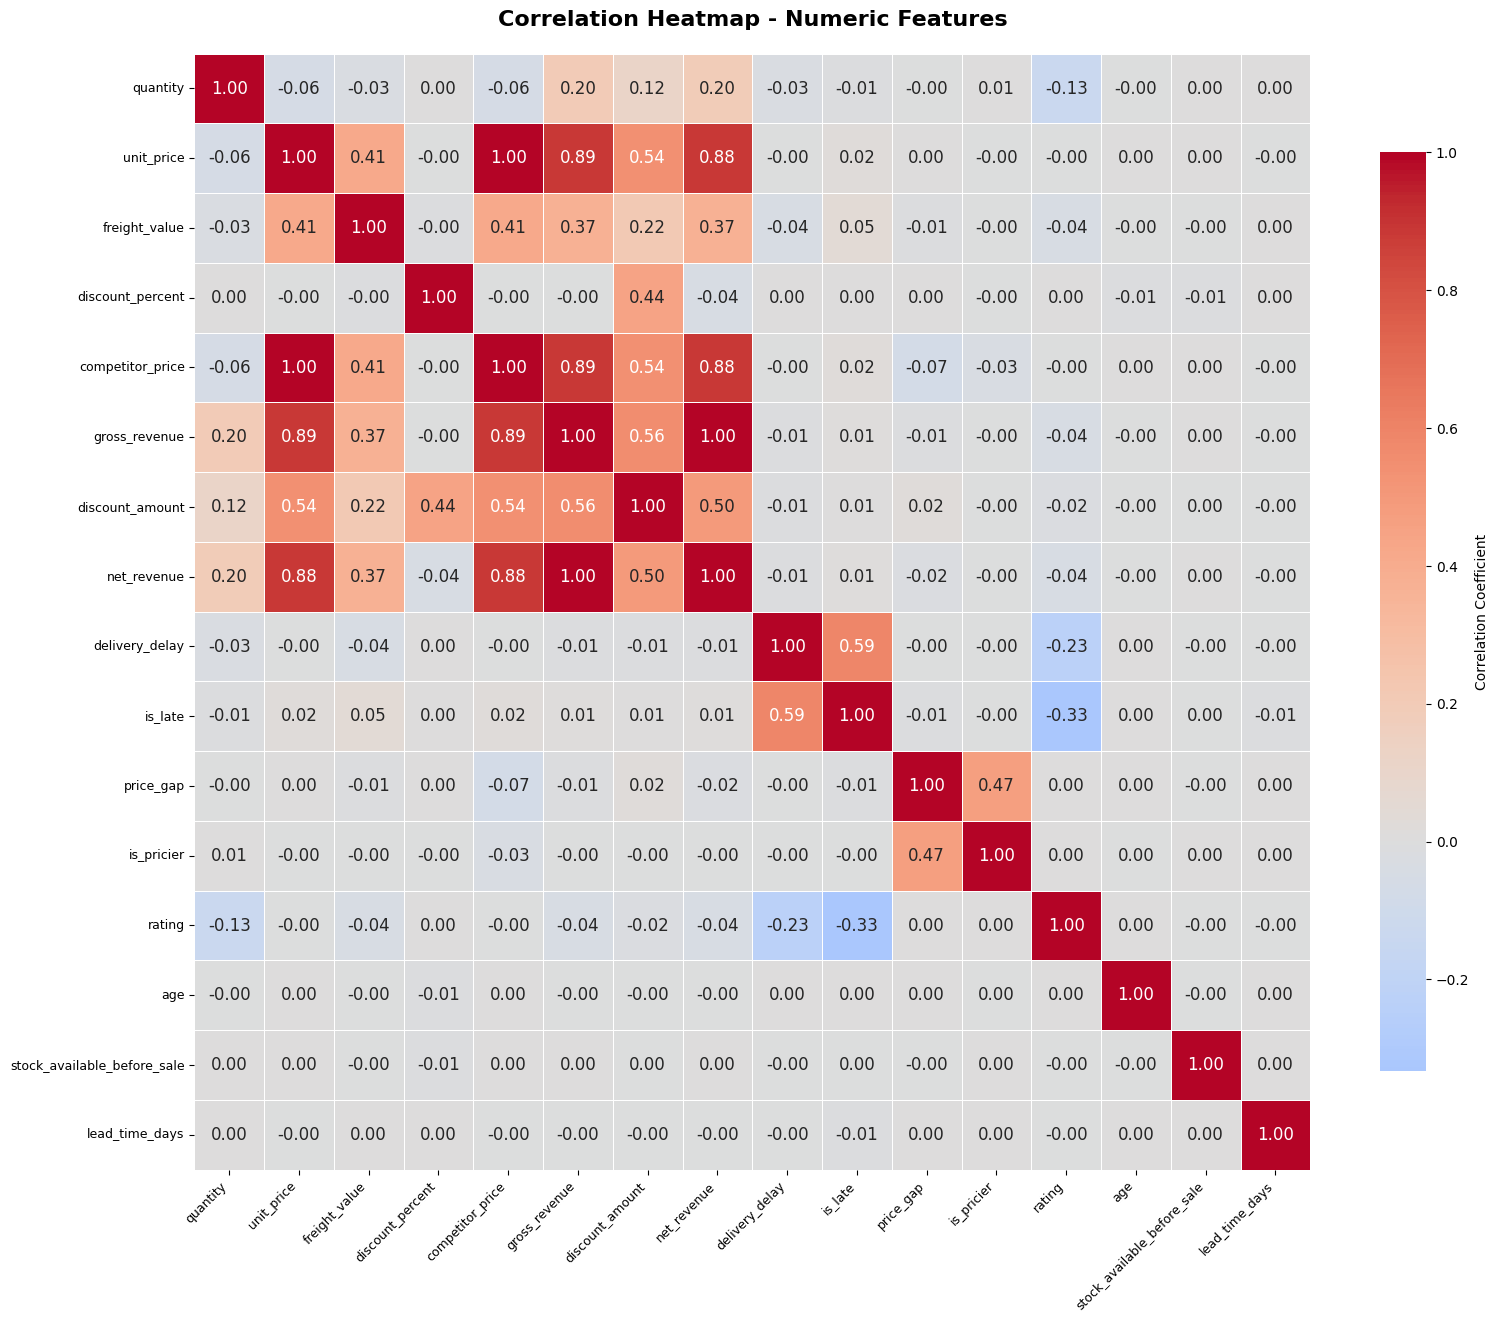

In [55]:
# Select numerical features for correlation analysis and heatmap visualization

numeric_cols = [
    'quantity', 'unit_price', 'freight_value',
    'discount_percent', 'competitor_price',
    'gross_revenue', 'discount_amount', 'net_revenue',
    'delivery_delay', 'is_late',
    'price_gap', 'is_pricier',
    'rating', 'age',
    'stock_available_before_sale', 'lead_time_days'
]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
    annot_kws={'size': 12},
    ax=ax
)

ax.set_title('Correlation Heatmap - Numeric Features', fontsize=16, fontweight='bold', pad=20)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)

fig.subplots_adjust(top=0.93)
plt.show()

**Insight 1 : Pricing Features Show Perfect Multicollinearity**
- **What happened?** `unit_price` and `competitor_price` are perfectly correlated (1.00). 
  Similarly, `gross_revenue` and `net_revenue` are perfectly correlated (1.00), and both 
  strongly correlate with `unit_price`/`competitor_price` (0.89).
- **ML meaning:** These features carry duplicate/redundant information. Including all of 
  them in a linear model would cause multicollinearity and unstable coefficients.
- **Business meaning:** Our product pricing tracks competitor pricing almost exactly — 
  we're not systematically over- or under-cutting the market.
**Action / recommendation:** Drop competitor_price and gross_revenue from any regression/ML model (keep only unit_price and net_revenue) to avoid unstable coefficients. For reporting, net_revenue should be the default metric since it already accounts for discounts/returns.

- **Limitation:** A correlation of 1.00 is suspicious on its own — it's worth checking whether competitor_price was actually engineered/simulated as a direct function of unit_price (e.g., unit_price * random_factor) rather than an independent real-world signal, since that would make it not a true "competitor" feature at all.
  

 **Insight 2 : Delivery Delay Is a Key Driver of Low Ratings**
- **What happened?** `is_late` correlates negatively with `rating` (-0.33), and 
  `delivery_delay` also shows a negative correlation with `rating` (-0.23). Meanwhile, 
  `delivery_delay` and `is_late` correlate positively with each other (0.59), as expected.
- **ML meaning:** Delivery-related features are among the few numeric features with a 
  meaningful (non-zero) relationship to `rating`, making them strong candidates for 
  Model 3 (Rating Prediction).
- **Business meaning:** Late or delayed deliveries are directly associated with lower 
  customer satisfaction.
- **Action / recommendation:** Prioritize is_late and delivery_delay as top features in Model 3 (Rating Prediction). From a business side, invest in reducing late deliveries (e.g., renegotiate SLAs with the slowest courier, add buffer to estimated delivery dates) since this is the strongest lever we have on customer satisfaction.
- **Limitation:** Correlation ≠ causation — a late delivery might be correlated with other issues (damaged product, wrong item) that are the real driver of the low rating rather than lateness itself. Also, -0.33 and -0.23 are moderate, not strong, correlations, so delivery delay alone won't fully explain rating variance.

#**Insight 3: Most Other Features Are Weakly or Not Correlated**

  **What happened?** Features like `age`, `stock_available_before_sale`, and 
  `lead_time_days` show near-zero correlation (≈0.00) with almost every other feature, 
  including revenue and rating.
- **ML meaning:** These features are largely independent — low risk of multicollinearity, 
  but also weak standalone linear predictive power for revenue/rating targets.
- **Business meaning:** Customer age and inventory/supplier metrics don't show a direct 
  linear relationship with pricing, revenue, or satisfaction.
- **Action / recommendation:** Deprioritize age, stock_available_before_sale, and lead_time_days as linear predictors, but don't drop them entirely — consider testing them in a non-linear model (e.g., tree-based) since near-zero linear correlation doesn't rule out non-linear relationships or interaction effects.
- **Limitation:** Pearson correlation only captures linear relationships. A feature like age could still matter through a non-linear pattern (e.g., very young and very old customers behave differently) that this heatmap can't detect.

# DataSet Time Range

In [56]:
print("From:", df['order_date'].min())
print("To:", df['order_date'].max())
print("Total days:", (df['order_date'].max() - df['order_date'].min()).days)

From: 2016-09-04 21:15:19
To: 2018-09-03 09:06:57
Total days: 728


# Orders Over Time 

In [75]:
import plotly.express as px

df['order_date'] = pd.to_datetime(df['order_date'])

orders_over_time = (
    df.groupby(df['order_date'].dt.to_period('M'))['order_id']
      .nunique()
      .reset_index(name='order_count')
)

orders_over_time['order_date'] = orders_over_time['order_date'].dt.to_timestamp()

fig = px.line(
    orders_over_time,
    x='order_date',
    y='order_count',
    markers=True,
    title='Orders Over Time (Monthly)',
    labels={
        'order_date': 'Order Date',
        'order_count': 'Number of Orders'
    }
)

fig.update_layout(
    width=1400,
    height=600,
    hovermode='x unified'
)

fig.show()

**Insight 1: Steady Growth Throughout 2017**

**What happened?** Orders grew consistently from near-zero in late 2016 to ~4,500 by October 2017, then spiked to the dataset's peak of ~7,220 orders in November 2017.

**ML meaning:** Strong upward trend + seasonality means any time-series/demand model needs explicit trend and seasonal terms (e.g., month dummies), not just a flat average.

**Business meaning:** The platform was in a healthy expansion phase throughout 2017, with November (Black Friday season) as the strongest month.
Action / recommendation: Use November 2017 as a benchmark for planning inventory/staffing/courier capacity ahead of future Black Friday periods.
Limitation: Only one year of "peak season" data is available (Nov 2017), so we can't yet confirm this is a recurring yearly pattern vs. a one-off spike.

**Insight 2:** Sharp Drop-Off at the End of the Dataset (Late 2018)

**What happened?** After holding steady at ~6,000–6,500 orders/month through mid-2018, order volume crashes to near-zero by September/October 2018.

**ML meaning:** This isn't a real demand signal — it's almost certainly incomplete data at the edge of the collection period. Including these final months as-is in a forecasting model would badly distort trend/seasonality estimates.

**Business meaning:** There's no evidence of an actual business collapse — this is a data coverage artifact, not a customer-behavior finding.
**Action / recommendation:** Truncate or exclude the last 1–2 months of the dataset before training any time-series model, and confirm the exact "data as-of" cutoff date with the data source.

**Limitation:** Without checking the raw order_purchase_timestamp max date and comparing it to when the dataset was extracted, we can't be 100% sure this is a cutoff artifact rather than a genuine event — it should be verified, not assumed.

**Insight 3:** December 2017 Dip After the November Peak

**What happened?** Orders dropped from ~7,220 in November 2017 down to ~5,000 in December 2017, before stabilizing and climbing again through mid-2018.

**ML meaning:** This confirms November was a genuine seasonal spike (not a step-change in baseline demand) — the series reverts toward trend right after.
Business meaning: Demand pulled forward into November (holiday shopping) likely came partly at the expense of December — a classic post-promotion demand dip.

**Action / recommendation:** Plan December marketing/promotions to smooth this dip rather than relying purely on November discounting.
Limitation: With only one year of data we can't separate "post-Black-Friday demand pull-forward" from other December-specific factors (e.g., shipping cutoffs before holidays affecting order timing).

# Revenue by Category

In [76]:
revenue_by_category = (
    df.groupby('category', observed=True)['net_revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.bar(
    revenue_by_category,
    x='net_revenue',
    y='category',
    orientation='h',
    labels={'net_revenue': 'Net Revenue', 'category': 'Category'},
    title='Revenue by Category'
)

fig.update_layout(
    yaxis={'categoryorder': 'total descending'},
    height=800
)

fig.show()

**Insight 1:** Revenue Is Heavily Concentrated in a Handful of Categories

**What happened?** beleza_saude leads with the highest net revenue (~1.2M), followed closely by cama_mesa_banho and esporte_lazer. After the top 3, revenue drops off sharply — most of the remaining ~40 categories generate a fraction of that.

**ML meaning:** This is a classic long-tail/Pareto distribution. If category is used as a feature, it needs target/frequency encoding (not one-hot) since dozens of categories have near-zero support and would create sparse, noisy dummy variables.

**Business meaning:** A small set of "hero categories" (health/beauty, home/bath, sports/leisure) drive the majority of revenue — these are the core of the business, not the long tail of niche categories.

**Action / recommendation:** Prioritize inventory, marketing budget, and supplier negotiations around the top 5–10 categories, since that's where revenue concentration (and risk) actually lives.

**Limitation:** High revenue doesn't necessarily mean high margin — beleza_saude could have thin margins offset by volume; net revenue alone doesn't tell us profitability per category.

**Insight 2:** A Long Tail of Low-Revenue Categories (Including an "Unknown" Bucket) Adds Noise

**What happened?** Most categories at the bottom of the chart contribute revenue so small it's barely visible on the 0–1.2M scale. Among them is a category labeled Unknown, meaning a number of orders have missing/unmapped product_category_name values.

**ML meaning:** These low-volume categories will have very few training samples each, risking overfitting or defaulting to the global average. The Unknown bucket specifically suggests missing categorical data that was imputed/defaulted during cleaning.

**Business meaning:** Many of these categories may not be worth the operational overhead relative to what they contribute, and the Unknown group means a chunk of revenue currently can't be attributed to any real category for strategy purposes.

**Action / recommendation:** Group the bottom ~30 categories into an "Other" bucket for reporting/modeling, and separately trace Unknown orders back to product_id to try to re-map them using product name/description before finalizing category-level conclusions.
Limitation: Low revenue doesn't always mean low strategic value (some categories may drive cross-sell), and without digging deeper we don't know if Unknown is a small edge case or a systematic gap from one seller/source.

# Revenue by Area

In [77]:
revenue_by_area = (
    df.groupby('area', observed=True)['net_revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    revenue_by_area,
    x='net_revenue',
    y='area',
    orientation='h',
    text='net_revenue',
    labels={
        'net_revenue': 'Net Revenue',
        'area': 'Area'
    },
    title='Top 10 Areas by Net Revenue'
)

fig.update_traces(
    texttemplate='%{text:.2s}',
    textposition='outside'
)

fig.update_layout(height=500)

fig.show()

**Insight:** SP Dominates Revenue, With a Steep Drop-Off Across the Rest of the Top 10

**What happened?** São Paulo (SP) alone generates 5.6M in net revenue — nearly 3x more than the next state, RJ (2.0M), and over 18x the 10th-ranked state, ES (~300k). The top 3 states (SP, RJ, MG) combined already dwarf the remaining 7.

**ML meaning:** area/state is a highly skewed categorical feature — one-hot encoding it naively would give SP disproportionate leverage in linear models; consider grouping low-revenue states into a broader region bucket or using target encoding instead.

**Business meaning:** Revenue is geographically concentrated in Brazil's Southeast (SP, RJ, MG), which likely reflects both population density and existing logistics infrastructure — this is where the core customer base and delivery network already work well.

**Action / recommendation:** Focus marketing spend and courier/warehouse investment on sustaining dominance in SP/RJ/MG, while treating expansion into lower-revenue states (like ES, DF, GO) as a separate, smaller-scale growth initiative rather than an equal priority.

**Limitation:** This chart shows raw revenue, not revenue per capita or per customer — SP's lead is partly just a function of it being Brazil's most populous state, so it doesn't necessarily mean SP customers are more valuable individually; that would need to be normalized to confirm.

# Average Quantity Sold by Discount Percentage

In [78]:
quantity_by_discount = (
    df.groupby('discount_percent', observed=True)['quantity']
    .mean()
    .reset_index()
)

fig = px.bar(
    quantity_by_discount,
    x='discount_percent',
    y='quantity',
    text='quantity',
    labels={
        'discount_percent': 'Discount Percentage (%)',
        'quantity': 'Average Quantity Sold'
    },
    title='Average Quantity Sold by Discount Percentage'
)

fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

fig.update_layout(
    height=500,
    xaxis=dict(dtick=5)
)

fig.show()

**Insight:** Discount Level Has No Meaningful Effect on Quantity Purchased
What happened? Average quantity sold per order stays essentially flat across all discount tiers (0%, 5%, 10%, 15%, 20%), ranging only from 1.19 to 1.22 units — a difference of just 0.03 units total.

**ML meaning:** discount_percent has near-zero predictive power for a quantity-based target, so it shouldn't be relied on as a driver feature in any model forecasting units sold; it may still matter for revenue-related targets, but not volume.

**Business meaning:** Discounting isn't encouraging customers to buy more items per order — most orders are essentially single-item purchases (~1.2 units) regardless of how deep the discount is.

**Action / recommendation:** Don't rely on discounts as a lever to increase basket size/quantity. If the goal is to drive more units per order, test bundling or "buy 2 get X% off" mechanics instead of flat percentage discounts, since flat discounts aren't moving this metric.

**Limitation:** This looks only at average quantity per order, not at whether discounts increased the number of orders or revenue — a flat quantity average doesn't rule out discounts working through a different channel (e.g., more customers ordering, just not more items each).

# Average Net Revenue by Discount

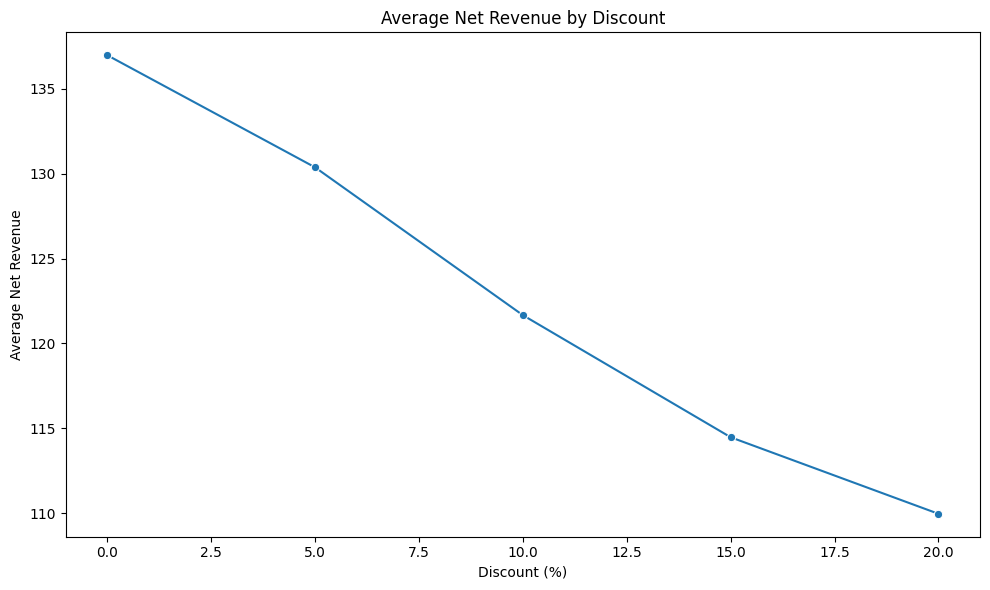

In [61]:
sales_discount = (
    df.groupby('discount_percent', observed=False)
      .agg(avg_net_revenue=('net_revenue', 'mean'))
      .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=sales_discount,
    x='discount_percent',
    y='avg_net_revenue',
    marker='o'
)

plt.title('Average Net Revenue by Discount')
plt.xlabel('Discount (%)')
plt.ylabel('Average Net Revenue')

plt.tight_layout()
plt.show()

**Insight:** Average Net Revenue Declines Steadily as Discount Percentage Increases

**What happened?** Average net revenue per order drops nearly linearly from ~137 at 0% discount down to ~110 at 20% discount — roughly a 20% decline in average order value across the discount range.

**ML meaning:** discount_percent shows a clear, fairly linear (mildly convex) negative relationship with net_revenue per order, making it a strong candidate feature for a revenue-prediction model — unlike quantity, which was flat across discount levels.

**Business meaning:** This looks less like "discounts drive revenue loss" and more like the arithmetic of discounting itself — a higher % off directly lowers net revenue per order, especially since (from the earlier chart) customers aren't buying more items to compensate.

**Action / recommendation**: Avoid framing this purely as "discounts are bad" — since quantity per order doesn't rise with discount, deep discounts (15–20%) are giving away margin without earning extra basket size in return. If discounts are meant to drive volume, they should be paired with a minimum basket size or bundle requirement rather than applied as a flat blanket percentage.

**Limitation:** This is average net revenue per order, which mechanically falls as discount % rises since net revenue is calculated post-discount — this chart shows the direct arithmetic effect of discounting, not necessarily that discounting is failing to attract customers or drive overall volume (that would need to be checked via order count by discount level, not just average value).

# Marketing Performance Analysis: Gross vs. Net Revenue

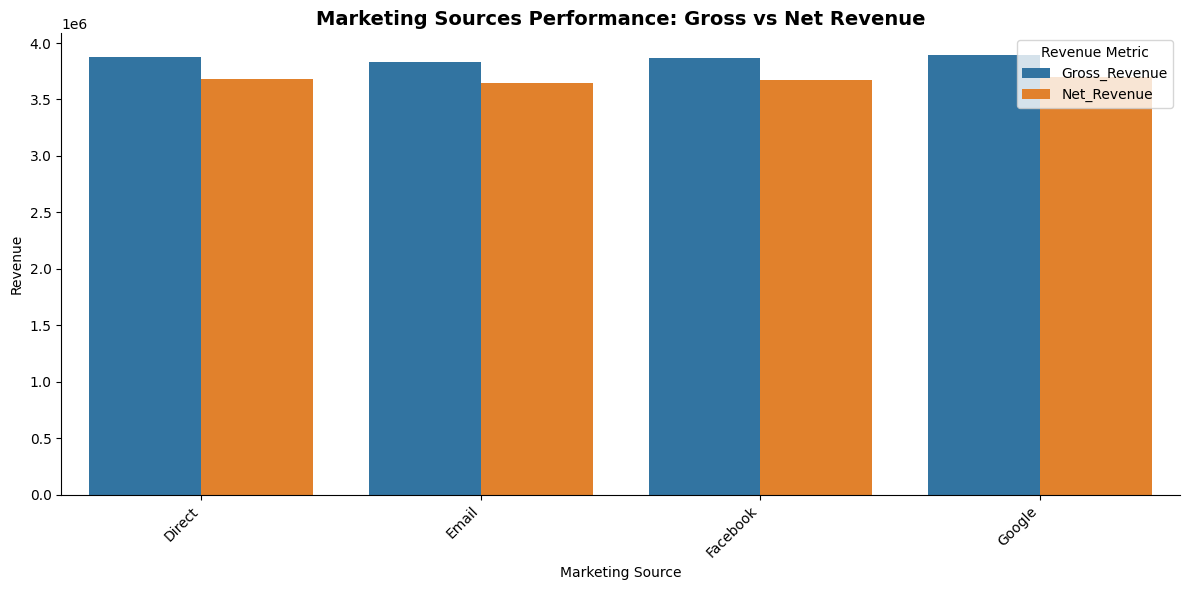

In [62]:
# 1. Aggregate marketing performance
marketing_summary = (
    df.groupby("marketing_source", observed=False)
    .agg(
        Gross_Revenue=("gross_revenue", "sum"),
        Net_Revenue=("net_revenue", "sum"),
        Avg_Discount=("discount_percent", "mean"),
        Total_Orders=("order_id", "count"),
    )
    .reset_index()
    .sort_values("Gross_Revenue", ascending=False)
)

# 2. Reshape data for plotting
revenue_data = marketing_summary.melt(
    id_vars="marketing_source",
    value_vars=["Gross_Revenue", "Net_Revenue"],
    var_name="Revenue_Type",
    value_name="Revenue",
)

# 3. Plot
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=revenue_data, x="marketing_source", y="Revenue", hue="Revenue_Type"
)

# 4. Formatting
plt.title(
    "Marketing Sources Performance: Gross vs Net Revenue",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Marketing Source")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Revenue Metric")

sns.despine()
plt.tight_layout()
plt.show()

🔵 **Gross Revenue**
= Total revenue before discounts/returns.

🟠 **Net Revenue**
= Net revenue after the discounts or returns that you calculated in the feature engineering.

### Insight: All Marketing Sources Perform Similarly, With No Standout Channel or Major Revenue Leakage
- **What happened?** Gross and net revenue are nearly identical across all four sources (Direct, Email, Facebook, Google), each landing in the ~3.8–4.0M gross / ~3.6–3.9M net range. Facebook and Google show the highest gross revenue by a small margin, but the gap between all four channels is minor.
- **ML meaning:** `marketing_source` has weak discriminative power on its own for revenue outcomes — since all channels behave almost identically, it's unlikely to be a strong standalone feature for a revenue model unless interacted with other variables (e.g., source × discount, source × category).
- **Business meaning:** No single acquisition channel is dramatically outperforming the others, and the gap between gross and net revenue (i.e., discount/return leakage) is consistently small and similar across all sources — there's no channel that's uniquely "leaking" more margin than the others.
- **Action / recommendation:** Since revenue performance is roughly even, channel prioritization should be based on **cost per acquisition / ROI**, not just revenue generated — pull marketing spend per channel if available and compare against this revenue to find the actually most efficient source, since this chart alone can't say which channel is most profitable.
- **Limitation:** This chart shows total revenue by source, not the number of orders or customers per channel — a channel could hit a similar revenue total with far fewer, higher-value orders (or many low-value ones), and this chart doesn't distinguish between those two very different scenarios.

# Courier Performance: Delivery Speed & Reliability

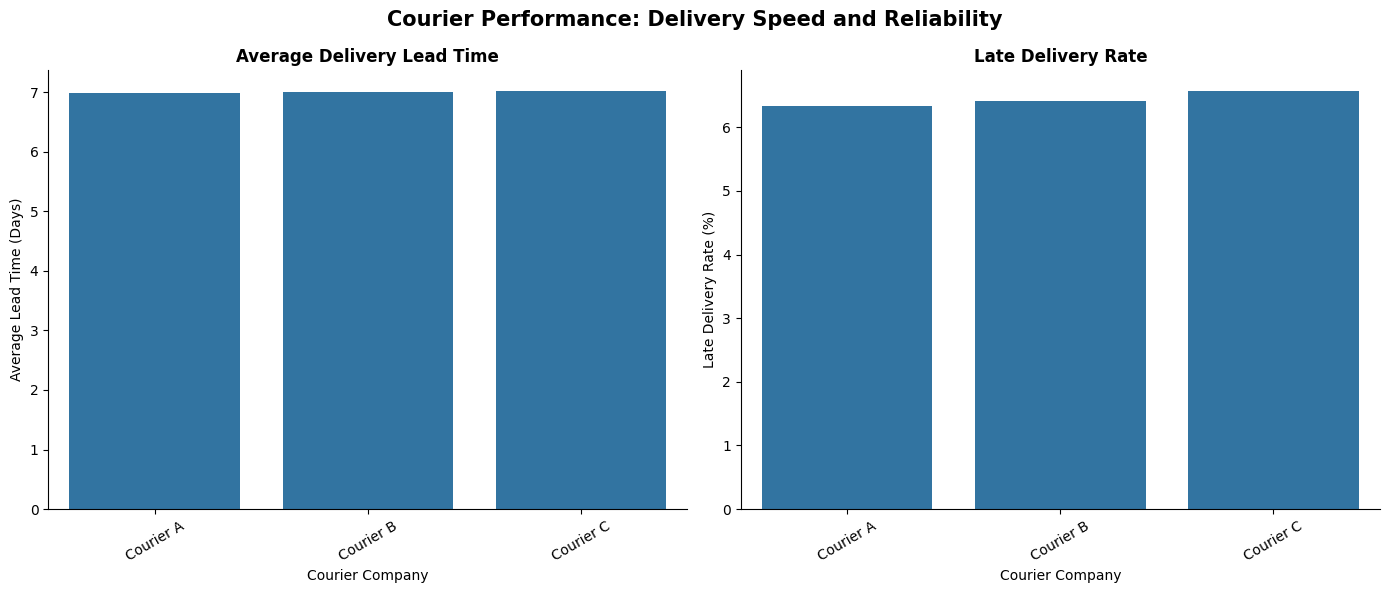

In [63]:
courier_summary = (
    df.groupby('courier', observed=False)
    .agg(
        avg_lead_time=('lead_time_days', 'mean'),
        late_delivery_rate=('is_late', 'mean'),
        total_shipments=('order_id', 'count')
    )
    .reset_index()
)

courier_summary['late_delivery_rate'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=courier_summary,
    x='courier',
    y='avg_lead_time',
    ax=axes[0]
)

axes[0].set_title('Average Delivery Lead Time', fontweight='bold')
axes[0].set_xlabel('Courier Company')
axes[0].set_ylabel('Average Lead Time (Days)')

sns.barplot(
    data=courier_summary,
    x='courier',
    y='late_delivery_rate',
    ax=axes[1]
)

axes[1].set_title('Late Delivery Rate', fontweight='bold')
axes[1].set_xlabel('Courier Company')
axes[1].set_ylabel('Late Delivery Rate (%)')

for ax in axes:
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(
    'Courier Performance: Delivery Speed and Reliability',
    fontsize=15,
    fontweight='bold'
)

sns.despine()
plt.tight_layout()
plt.show()

### Insight: Couriers A, B, and C Perform Nearly Identically — Courier Choice Isn't the Main Delivery Problem
- **What happened?** All three couriers average close to 7 days per shipment and have late-delivery rates in a tight 6–7% band. Courier A has the lowest late-delivery rate (slightly more reliable), Courier C the highest, but the spread between them is small.
- **ML meaning:** `courier` likely has weak standalone predictive power for `is_late` or `delivery_delay` — the earlier correlation heatmap already showed delivery delay was more tied to lateness itself than to other features, and this confirms courier identity isn't the dominant driver either.
- **Business meaning:** Since all three couriers perform about the same, switching volume between them or renegotiating with the "best" one (Courier A) probably won't meaningfully reduce late deliveries — the real bottleneck likely sits elsewhere (e.g., specific regions, order processing time before handoff, or seasonal demand spikes).
- **Recommendation:** The business should redirect investigation toward other delivery-delay drivers — breaking lateness down by `area`/state or by time period (e.g., November 2017 peak) instead of by courier, since courier doesn't appear to explain much of the variation.
- **Limitation:** We don't know the shipment volume each courier actually handles — if one courier handles far fewer or more difficult routes (e.g., more remote states), a fair reliability comparison would need to control for that rather than treating all three as directly comparable.

# Net Revenue by Brazilian State

In [64]:
state_coords = {
    'AC': (-9.0238, -70.8120), 'AL': (-9.5713, -36.7820), 'AM': (-3.4168, -65.8561),
    'AP': (1.4090, -51.7700), 'BA': (-12.5797, -41.7007), 'CE': (-5.4984, -39.3206),
    'DF': (-15.7998, -47.8645), 'ES': (-19.1834, -40.3089), 'GO': (-15.8270, -49.8362),
    'MA': (-4.9609, -45.2744), 'MG': (-18.5122, -44.5550), 'MS': (-20.7722, -54.7852),
    'MT': (-12.6819, -56.9211), 'PA': (-3.9019, -52.4790), 'PB': (-7.2400, -36.7820),
    'PE': (-8.8137, -36.9541), 'PI': (-8.5000, -42.6000), 'PR': (-24.8949, -51.5350),
    'RJ': (-22.1000, -43.2000), 'RN': (-5.4026, -36.9541), 'RO': (-10.9472, -62.8182),
    'RR': (1.9981, -61.3300), 'RS': (-30.0346, -53.4189), 'SC': (-27.2423, -50.2189),
    'SE': (-10.5741, -37.3857), 'SP': (-22.1900, -48.7900), 'TO': (-10.1753, -48.2982)
}

revenue_by_area_full = (
    df.groupby('area', observed=True)['net_revenue']
    .sum()
    .reset_index()
)

revenue_by_area_full['lat'] = revenue_by_area_full['area'].map(
    lambda s: state_coords.get(s, (None, None))[0]
)
revenue_by_area_full['lon'] = revenue_by_area_full['area'].map(
    lambda s: state_coords.get(s, (None, None))[1]
)

revenue_by_area_full = revenue_by_area_full.dropna(subset=['lat', 'lon'])

fig = px.scatter_geo(
    revenue_by_area_full,
    lat='lat',
    lon='lon',
    size='net_revenue',
    color='net_revenue',
    hover_name='area',
    color_continuous_scale='Blues',
    scope='south america',
    labels={'net_revenue': 'Net Revenue'},
    title='Net Revenue by Brazilian State',
    size_max=40
)

fig.update_traces(
    marker=dict(
        line=dict(width=1, color='#333'),
        sizemin=6
    )
)

fig.update_geos(
    fitbounds='locations',
    visible=True,
    landcolor='rgb(235,235,235)',
    showcountries=True
)

fig.update_layout(
    height=500,
    width=800,
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0}
)

fig.show()

### Insight: Revenue Is Heavily Concentrated in the Southeast Region, With SP as a Clear Standout
- **What happened?** One state (visibly São Paulo, in the São Paulo/Southeast area) shows a dramatically larger, darker circle than every other state, consistent with the ~5.6M net revenue seen earlier. The next tier of noticeably larger circles cluster right around it — likely RJ and MG — while most of the other ~24 states appear as small, light circles scattered across the north, northeast, and south.
- **ML meaning:** This confirms `area`/state is a highly imbalanced categorical feature geographically as well as numerically — the Southeast cluster (SP, RJ, MG) should probably be treated as a distinct segment from the rest of the country in any regional modeling or segmentation approach, rather than treating all 27 states as equally weighted categories.
- **Business meaning:** Revenue isn't just concentrated in one state in isolation — it's concentrated in a specific *region* (Southeast Brazil), which likely reflects that this region has the country's highest population density and most mature logistics/delivery infrastructure, reinforcing what the "Top 10 Areas by Net Revenue" bar chart already showed.
- **Recommendation:** The business should treat the Southeast (SP/RJ/MG) as the core, defend-and-grow market — protecting delivery SLAs and inventory availability there — while evaluating northern/northeastern states as a separate expansion track with its own logistics investment case, since they currently show minimal revenue.
- **Limitation:** This map shows total revenue by state, not revenue per capita or per customer, so it doesn't tell us whether Southeast customers are individually more valuable or simply more numerous — that distinction would need a normalized (per-customer or per-capita) view to confirm.

In [65]:
df['rating'].value_counts(dropna=False)

rating
5.0    63525
4.0    21315
1.0    14235
3.0     9423
2.0     3874
NaN      942
Name: count, dtype: int64

# Rating Distribution

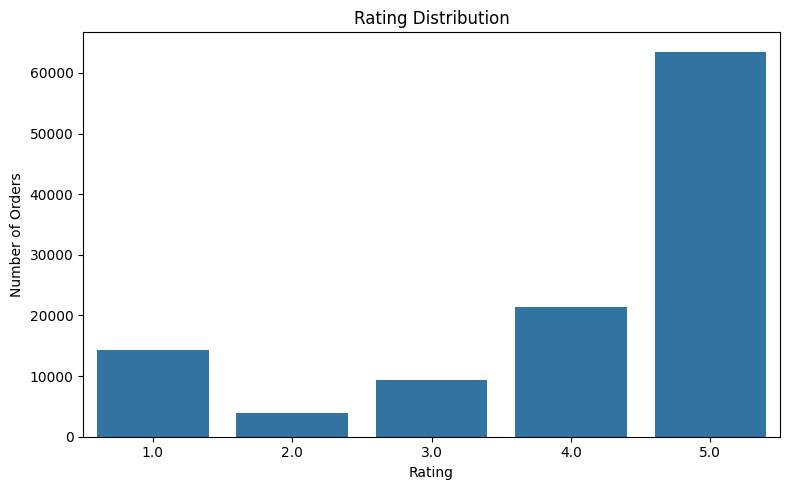

In [66]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='rating',
    order=sorted(df['rating'].dropna().unique())
)

plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### Insight: Ratings Are Heavily Skewed Toward 5.0, With a Notable "J-Shape" — Even 1.0 Outnumbers 2.0 and 3.0
- **What happened?** The 5.0 rating dominates with over 60,000 orders — far more than every other rating combined. But the distribution isn't a smooth decline: 1.0 (~14,000) is actually higher than both 2.0 (~4,000) and 3.0 (~9,500), creating a small secondary bump at the very bottom of the scale.
- **ML meaning:** This is a classic J-shaped/bimodal rating distribution, common in review data — it means `rating` as a regression target will be dominated by the 5.0 class, so a model minimizing average error could just predict "5" for everything and look deceptively accurate. If this feeds a classification task, it likely needs class weighting or should be reframed as a binary "satisfied (4-5) vs. not (1-3)" problem instead of true 5-class prediction.
- **Business meaning:** Most customers who bother to leave a rating are happy, but there's a distinct group of clearly dissatisfied customers (1.0) that's larger than the "mildly disappointed" middle (2.0, 3.0) — dissatisfaction here tends to be extreme rather than moderate, which usually points to a specific breaking point (like a failed/late delivery) rather than general product mediocrity.
- **Recommendation:** The business should treat 1.0-rated orders as a distinct investigation segment rather than lumping them with 2.0–3.0 as "mildly negative" — since we already saw delivery delay correlates with low ratings, cross-referencing 1.0-rated orders specifically against `is_late`/`delivery_delay` could isolate the main driver of the worst-case customer experience.
- **Limitation:** This chart doesn't separate ratings by category, region, or time, so we can't yet tell if the 1.0 bump is concentrated in specific products/sellers/periods or spread evenly across the business — and self-selection bias in who leaves a review at all (happy or furious customers rate more than neutral ones) likely inflates both extremes relative to true average satisfaction.

# Top & Bottom 5 Categories by Average Rating

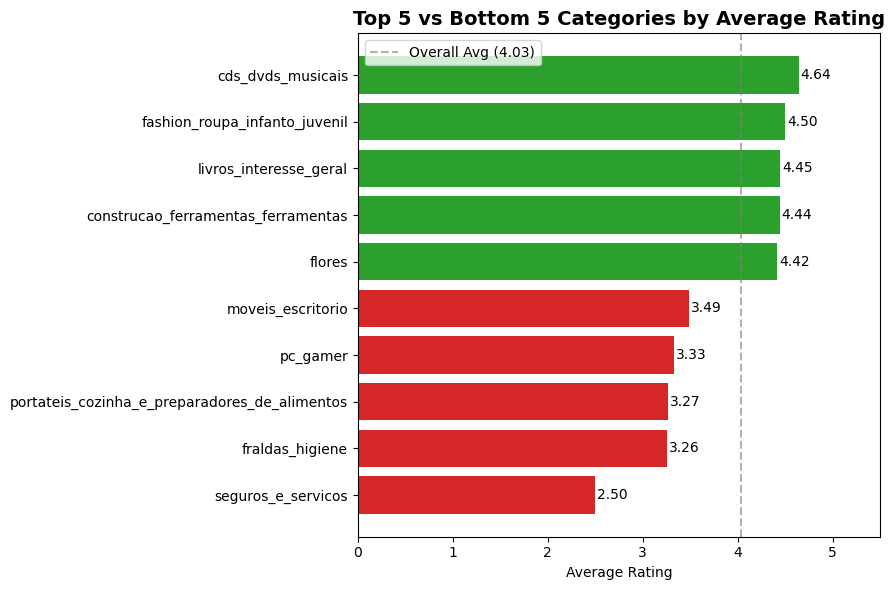

In [68]:
# Define the top and bottom categories by average rating
category_ratings = df.groupby('category', observed=False)['rating'].mean().dropna()
top_5 = category_ratings.nlargest(5)
bottom_5 = category_ratings.nsmallest(5)

# Now plot them
combined = pd.concat([top_5, bottom_5]).sort_values()

colors = ['#d62728' if v in bottom_5.values else '#2ca02c' for v in combined.values]

plt.figure(figsize=(9, 6))
bars = plt.barh(combined.index, combined.values, color=colors)

for bar, val in zip(bars, combined.values):
    plt.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
              va='center', fontsize=10)

plt.xlabel('Average Rating')
plt.title('Top 5 vs Bottom 5 Categories by Average Rating', fontsize=14, fontweight='bold')
plt.xlim(0, 5.5)
plt.axvline(x=df['rating'].mean(), color='gray', linestyle='--', alpha=0.6, label=f'Overall Avg ({df["rating"].mean():.2f})')
plt.legend()
plt.tight_layout()
plt.show()


### Insight: Category Ratings Split Cleanly Around the Overall Average — Bottom Categories Are the Real Concern, Not the Top
- **What happened?** The top 5 categories (`cds_dvds_musicais` at 4.64, down to `flores` at 4.42) all sit comfortably above the overall average of 4.03. But the bottom 5 fall well below it, with `seguros_e_servicos` (Insurance & Services) at just 2.50 — over 1.5 points below average and by far the worst performer, followed by `fraldas_higiene` and `portateis_cozinha_e_preparadores_de_alimentos` both around 3.26–3.27.
- **ML meaning:** Category is a meaningful signal for `rating`, but the effect isn't symmetric — the top categories cluster tightly just above average (a ~0.2 point spread among the top 5), while the bottom categories are much more spread out and further from the mean (a ~1.0 point spread among the bottom 5). This asymmetry means category encoding should capture the *severity* of underperformance, not just rank.
- **Business meaning:** There's no single "star category" driving overall satisfaction — the top performers are only modestly above average. The real story is a handful of categories, especially `seguros_e_servicos`, dragging down customer experience significantly more than any category is lifting it up.
- **Recommendation:** The business should treat `seguros_e_servicos` as a priority investigation, not a routine one — a gap this large (2.50 vs. 4.03 average) suggests a structural problem (e.g., product-market fit, unclear terms, poor support) rather than routine variability, and it's worth checking order volume for this category to see how much overall satisfaction it's dragging down.
- **Limitation:** This ranks categories by mean rating alone, without showing order volume per category — a category with very few orders could have an extreme average driven by just a handful of reviews, so before acting on `seguros_e_servicos` specifically, its sample size needs to be checked to confirm the 2.50 average is statistically meaningful and not noise from a small number of orders.

# Delivery Delay & Customer Rating

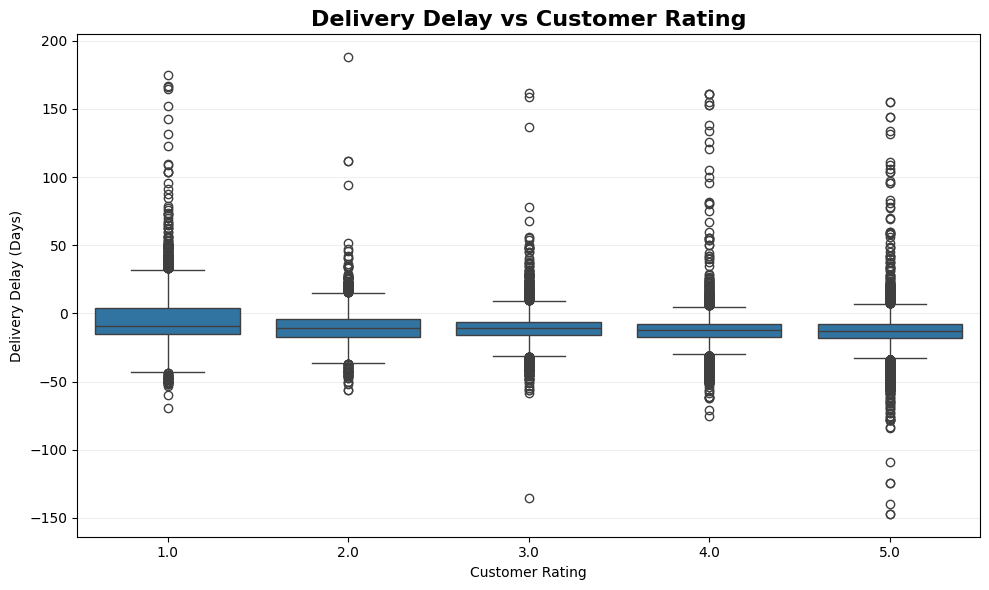

In [69]:
delay_rating = df.dropna(subset=['delivery_delay', 'rating'])

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=delay_rating,
    x='rating',
    y='delivery_delay'
)

plt.title('Delivery Delay vs Customer Rating',
          fontsize=16, fontweight='bold')

plt.xlabel('Customer Rating')
plt.ylabel('Delivery Delay (Days)')

plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

### Insight: Early Deliveries (Negative Delay) Are the Norm, and Rating 5.0 Has Its Own Extreme Outlier Cluster
- **What happened?** Median `delivery_delay` is negative (below 0) across every rating group, meaning most orders arrive *before* the estimated date rather than late — that's consistent with 4.0 and 5.0 ratings having tight boxes centered just under 0. But rating 1.0 shows the widest spread and heaviest late-delivery outliers (up to +180 days), while rating 5.0 uniquely also has a cluster of extreme *early* outliers (down to -150 days) that no other rating group shows as prominently.
- **ML meaning:** `delivery_delay` is genuinely informative for rating prediction, but its relationship isn't purely "later = worse" — it's the *magnitude* of deviation from the expected delivery date (in either direction) that seems to matter, not just lateness. A model should probably use `abs(delivery_delay)` or separate early/late flags rather than treating delay as a single linear driver.
- **Business meaning:** Customers are overwhelmingly tolerant of (or even reward) early delivery, and severe lateness clearly drives 1.0 ratings. But the unexpected early-outlier cluster at rating 5.0 (some orders arriving ~150 days early) is unusual enough that it's worth checking whether these are genuine deliveries or a data artifact (e.g., an incorrect estimated-delivery-date field for certain orders).
- **Recommendation:** The business should prioritize tightening the *estimated* delivery date accuracy, not just physical delivery speed — since lateness relative to the promise (not delivery speed itself) appears to be what drives dissatisfaction, and the 5.0 early-outlier cluster suggests some estimated dates may be set unrealistically far out to begin with.
- **Limitation:** This chart can't distinguish whether the extreme early outliers at rating 5.0 reflect real operational wins or a data quality issue in how `Expected_Delivery_Days` was recorded for those specific orders — that would need to be checked against the raw order records before drawing a business conclusion from that particular cluster.

# Investigating Extreme Early Delivery Cases

In [70]:
df['expected_lead_time'] = (
    pd.to_datetime(df['expected_delivery_date']) -
    pd.to_datetime(df['order_date'])
).dt.days

extreme_early = df[df['delivery_delay'] <= -100]

print(
    extreme_early[
        ['order_id',
         'order_date',
         'expected_delivery_date',
         'actual_delivery_date',
         'expected_lead_time',
         'delivery_delay',
         'rating']
    ].sort_values('delivery_delay').head(20)
)

                                order_id          order_date  \
2698    0607f0efea4b566f1eb8f7d3c2397320 2018-03-06 09:47:07   
2699    0607f0efea4b566f1eb8f7d3c2397320 2018-03-06 09:47:07   
88249   c72727d29cde4cf870d569bf65edabfd 2017-02-07 18:01:15   
105732  eec7f369423b033e549c02f3c5381205 2018-02-06 20:44:56   
86246   c2bb89b5c1dd978d507284be78a04cb2 2017-05-23 22:28:36   
86245   c2bb89b5c1dd978d507284be78a04cb2 2017-05-23 22:28:36   
28683   40dc2ba6f322a17626aac6244332828c 2017-10-05 21:39:05   

       expected_delivery_date actual_delivery_date  expected_lead_time  \
2698               2018-08-03  2018-03-09 23:36:47                 149   
2699               2018-08-03  2018-03-09 23:36:47                 149   
88249              2017-07-04  2017-02-14 14:27:45                 146   
105732             2018-07-12  2018-02-27 16:35:43                 155   
86246              2017-10-11  2017-06-09 13:35:54                 140   
86245              2017-10-11  2017-06-09 1

**Extreme negative delivery delays are caused by unusually long expected delivery times in some orders, indicating a potential issue with the expected delivery date data.**

# Top 10 Product Categories by Low Stock Rate

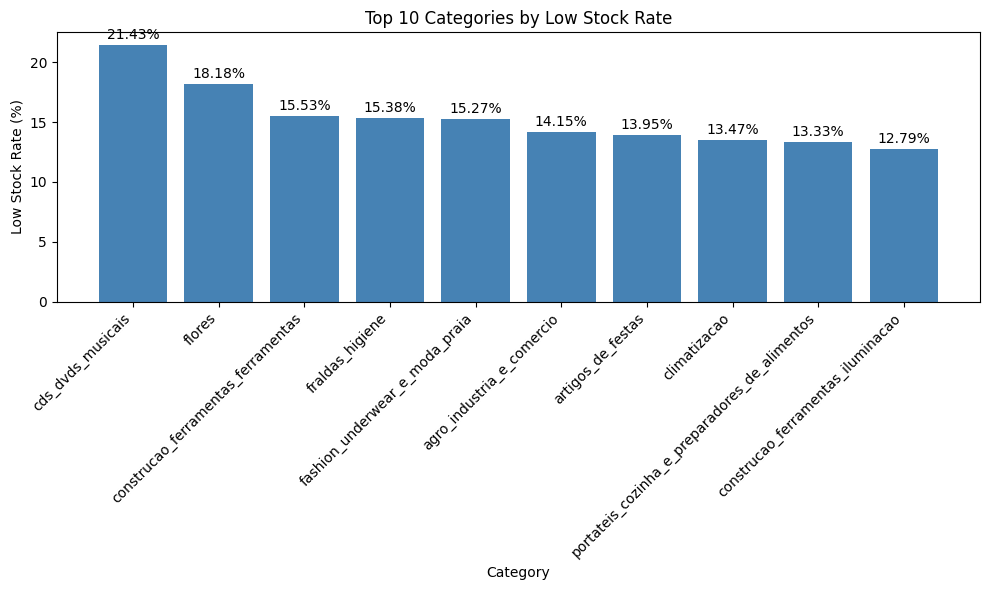

In [71]:
low_stock_rate = (
    df.groupby('category', observed=False)['low_stock_flag']
      .mean()
      .sort_values(ascending=False)
      * 100
)
top10 = low_stock_rate.head(10).round(2)
 
plt.figure(figsize=(10, 6))
plt.bar(top10.index, top10.values, color='steelblue')
plt.title('Top 10 Categories by Low Stock Rate')
plt.xlabel('Category')
plt.ylabel('Low Stock Rate (%)')
plt.xticks(rotation=45, ha='right')
 
for i, v in enumerate(top10.values):
    plt.text(i, v + 0.5, f'{v}%', ha='center')
 
plt.tight_layout()
plt.show()

### Insight
- **What happened?** The category cds_dvds_musicais has the highest low-stock rate at 21.43%, followed by flores at 18.18%, with the rest of the top 10 categories clustering between 12.79% and 15.53%.
- **ML meaning:** Category shows up as a meaningful signal for predicting stockouts, so it's worth encoding as a feature in any predictive model — possibly even engineering a "high-risk category" flag for these top offenders.
- **Business meaning:** Products in these categories (especially CDs/DVDs and flowers) are prone to running out of stock frequently, which can translate into lost sales and poor customer experience when demand hits.
- **Action / recommendation:** Prioritize reviewing reorder policies for these specific categories — consider raising safety stock levels or shortening supplier lead times for them.
- **Limitation:** These rates are based on a single time window, and the data doesn't distinguish between stockouts driven by high demand versus supply-side issues, so further data would be needed to pin down the actual cause.

# Age Group Analysis

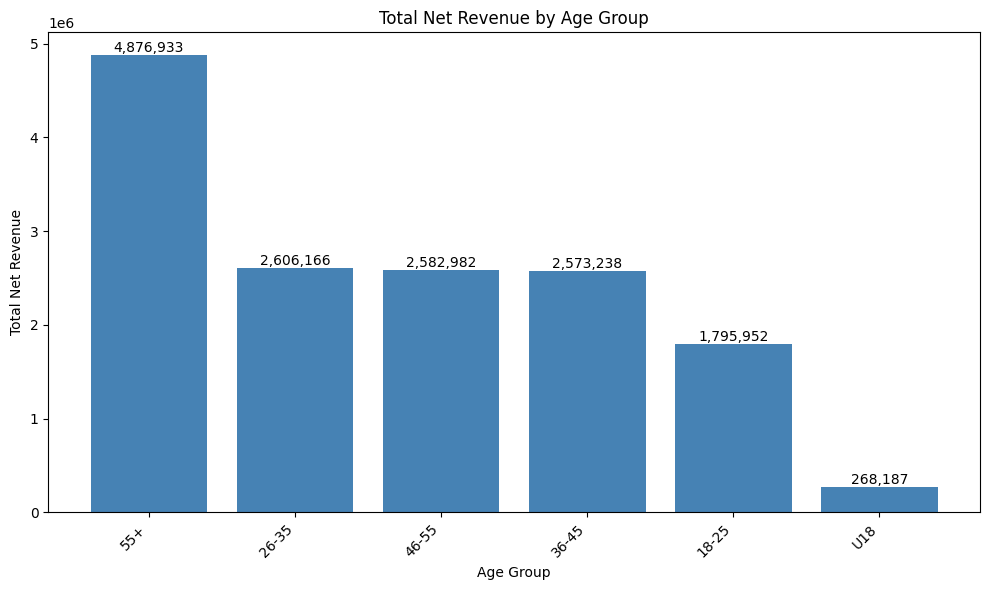

In [72]:
age_analysis = (
    df.groupby('age_group', observed=False)
      .agg(
          orders=('order_id', 'nunique'),
          total_quantity=('quantity', 'sum'),
          total_net_revenue=('net_revenue', 'sum'),
          avg_rating=('rating', 'mean')
      )
      .sort_values('total_net_revenue', ascending=False)
)
avg_rating_by_category = (
    df.groupby('category', observed=False)['rating']
      .mean()
      .sort_values(ascending=False)
)

top_5 = avg_rating_by_category.head(5)
bottom_5 = avg_rating_by_category.tail(5)
plt.figure(figsize=(10, 6))
plt.bar(age_analysis.index.astype(str), age_analysis['total_net_revenue'], color='steelblue')
plt.title('Total Net Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Net Revenue')
plt.xticks(rotation=45, ha='right')
 
for i, v in enumerate(age_analysis['total_net_revenue']):
    plt.text(i, v, f'{v:,.0f}', ha='center', va='bottom')
 
plt.tight_layout()
plt.show()


**Insight**
-**What happened?**
The 55+ age group generates the highest total net revenue (4,876,933) — nearly double the next closest group (26-35 at 2,606,166) — while the U18 group trails far behind at just 268,187.

**ML meaning:** Age group is a strong differentiator for revenue contribution, so it's a useful feature for revenue prediction or customer segmentation models. Given the sharp drop-off for U18, this group may also need separate handling to avoid skewing model averages.

**Business meaning:** The 55+ segment is the core revenue driver for the business, while younger customers (especially U18) contribute minimally — suggesting the current product mix or marketing may not resonate with younger buyers.

**Action / recommendation:** Double down on retention and loyalty programs for the 55+ segment since they drive the most value, while investigating why U18 and 18-25 groups underperform (pricing, product fit, marketing channels) to unlock growth there.

**Limitation:** Revenue alone doesn't account for group size — if the 55+ group simply has more customers or higher average spend per capita, that's a different story than 55+ being individually more valuable. Would need order count and revenue-per-customer to confirm.

# Payment Method Analysis

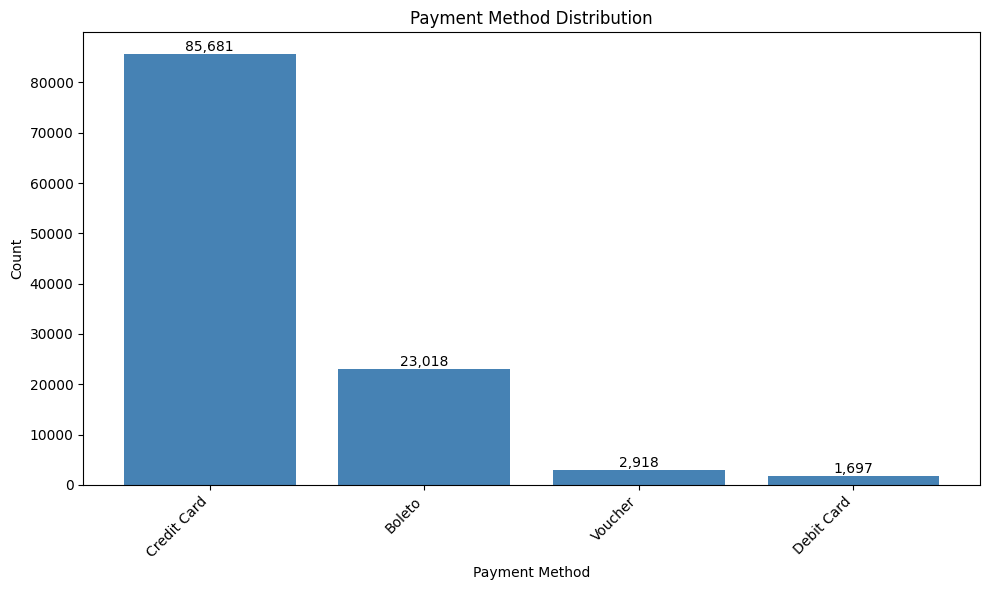

In [73]:
payment_counts = df['payment_method'].value_counts().head(10)
 
plt.figure(figsize=(10, 6))
plt.bar(payment_counts.index.astype(str), payment_counts.values, color='steelblue')
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
 
for i, v in enumerate(payment_counts.values):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')
 
plt.tight_layout()
plt.show()
 

### Insight
- **What happened?** Credit Card dominates as the payment method with 85,681 orders, far ahead of Boleto (23,018), while Voucher (2,918) and Debit Card (1,697) are used rarely.
- **ML meaning:** Payment method is a highly imbalanced categorical feature — Credit Card alone makes up the vast majority of records, so any model using this feature should watch for it overpowering rarer categories, and rare classes like Debit Card may need grouping ("Other") to avoid sparse-data issues.
- **Business meaning:** Customers strongly prefer Credit Card and Boleto for checkout, meaning the platform's payment infrastructure and any transaction fees/incentives should prioritize smooth support for these two methods.
- **Action / recommendation:** Ensure Credit Card and Boleto payment flows are optimized (low friction, fast approval) since they drive the bulk of orders, and consider investigating why Voucher and Debit Card usage is so low — it could be a UX issue, limited availability, or genuine low demand.
- **Limitation:** This shows order counts, not revenue or customer value per payment method — a method with fewer orders could still have higher average order value. Also no visibility into failed/abandoned payments by method.

# Net Revenue by Weather

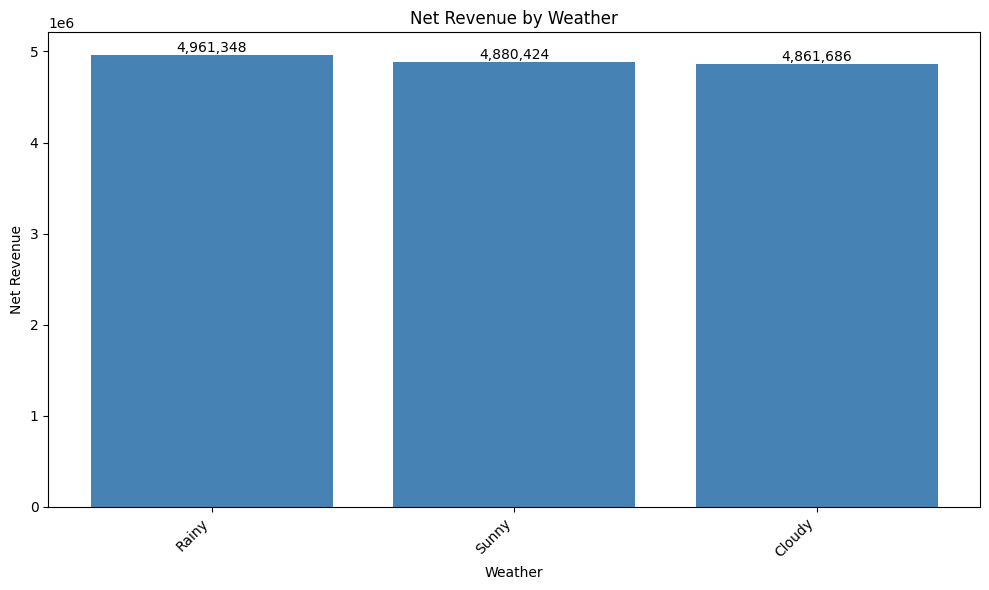

In [74]:
weather_revenue = (
    df.groupby('weather', observed=False)['net_revenue']
      .sum()
      .sort_values(ascending=False)
      .round(2)
)
 
plt.figure(figsize=(10, 6))
plt.bar(weather_revenue.index.astype(str), weather_revenue.values, color='steelblue')
plt.title('Net Revenue by Weather')
plt.xlabel('Weather')
plt.ylabel('Net Revenue')
plt.xticks(rotation=45, ha='right')
 
for i, v in enumerate(weather_revenue.values):
    plt.text(i, v, f'{v:,.0f}', ha='center', va='bottom')
 
plt.tight_layout()
plt.show()

### Insight
- **What happened?** Rainy weather generated the highest net revenue at 4,961,348, followed closely by Sunny (4,880,424) and Cloudy (4,861,686) — a spread of less than 2% across all three conditions.
- **ML meaning:** Weather shows almost no discriminative power for revenue in this dataset, so it's likely a weak or low-priority feature for a revenue prediction model — including it may add noise more than signal unless combined with other variables (e.g., category or region).
- **Business meaning:** Overall sales volume is stable regardless of weather, suggesting the business isn't meaningfully weather-dependent at an aggregate level — customers keep buying regardless of conditions.
- **Action / recommendation:** Don't prioritize weather-based promotions or inventory adjustments at the aggregate level; instead, check if weather effects show up only within specific categories (e.g., umbrellas, seasonal goods) where the impact might be hidden by aggregation.
- **Limitation:** This is a simple sum comparison across only 3 weather categories — it doesn't control for other factors (season, day of week, promotions) that could be confounding the true weather effect, and doesn't test statistical significance.